# REPORT: SOLAR ENERGY ADOPTION IN AUSTRALIA BY STATES #

**Author**: Quan Mai 
**Date**: 4th October 2026

## Initial import and data setup ##
**External data source: https://www.abs.gov.au/census/find-census-data/datapacks**

In [1]:
import pandas as pd
import numpy as np

try:
    # Load the internal datasets
    df_capacity = pd.read_csv('sgu-solar-capacity-2011-to-present-and-totals.csv')
    df_installations = pd.read_csv('sgu-solar-installations-2011-to-present-and-totals.csv')
    df_postcodes = pd.read_csv('australian_postcodes.csv')
    df_population = pd.read_csv('Population_by_State 2011_2025.csv')
    
    # Load the external datasets
    df_census_21 = pd.read_csv("external datasets/2021Census_G37_AUST_STE.csv")
    df_census_16 = pd.read_csv("external datasets/2016Census_G33_AUS_STE.csv")
    df_census_11 = pd.read_csv("external datasets/2011Census_B32_AUST_STE_short.csv")



    print("Data Gathering Successful. All files loaded.")
except Exception as e:
    print(f"Error loading files: {e}")

Data Gathering Successful. All files loaded.


## Understanding the initial data state ##
### visualizing the datasets ###

In [2]:
print("--- Solar Capacity Dataset --- ")
df_capacity.info() 
display(df_capacity.describe())
display(df_capacity.head())
display(df_capacity.tail())


--- Solar Capacity Dataset --- 
<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Columns: 178 entries, Small Unit Postcode to Total Rated Power Output In kW
dtypes: float64(177), int64(1)
memory usage: 3.8 MB


,Small Unit Postcode,Historic Total Rated Power Output In kW (2001 - 2010),Jan 2011 - Rated Power Output In kW,Feb 2011 - Rated Power Output In kW,Mar 2011 - Rated Power Output In kW,Apr 2011 - Rated Power Output In kW,May 2011 - Rated Power Output In kW,Jun 2011 - Rated Power Output In kW,Jul 2011 - Rated Power Output In kW,Aug 2011 - Rated Power Output In kW,...,Nov 2024 - Rated Power Output In kW,Dec 2024 - Rated Power Output In kW,Jan 2025 - Rated Power Output In kW,Feb 2025 - Rated Power Output In kW,Mar 2025 - Rated Power Output In kW,Apr 2025 - Rated Power Output In kW,May 2025 - Rated Power Output In kW,Jun 2025 - Rated Power Output In kW,Jul 2025 - Rated Power Output In kW,Total Rated Power Output In kW
count,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,...,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000
mean,4168.266548,180.258767,20.679269,22.982555,28.511664,27.042775,41.266189,59.553616,19.254452,20.140893,...,96.599781,113.245737,63.394109,80.743511,83.354635,70.931454,70.325591,52.031738,42.526434,9575.233955
std,1592.968085,300.729756,42.076633,43.400588,51.380393,48.560529,75.581136,105.559607,37.929121,39.546335,...,171.460774,209.621779,124.060835,150.836322,149.111981,132.374325,132.808058,103.070242,84.652508,15602.295013
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.080000
25%,2845.250000,9.690000,0.000000,0.000000,0.000000,0.000000,0.000000,2.752500,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,769.946500
50%,3929.500000,61.752000,4.560000,6.110000,8.150000,7.512000,12.685000,19.337500,3.995000,4.940000,...,32.552500,37.840000,18.500000,25.960000,29.480000,22.575000,22.285000,13.200000,10.450000,3572.203500
75%,5340.750000,222.033500,23.756000,26.801250,34.588750,32.378750,47.706000,70.321250,20.558750,20.415000,...,122.855000,139.858750,75.732500,96.346250,105.112500,85.360000,83.186250,57.765000,48.681250,11895.593500
max,9729.000000,3164.003000,754.484000,572.100000,566.300000,470.395000,770.705000,1225.978000,355.611000,516.160000,...,2179.230000,3111.890000,1861.760000,1974.510000,2077.895000,1790.775000,1721.985000,1287.500000,960.645000,165866.824000


,Small Unit Postcode,Historic Total Rated Power Output In kW (2001 - 2010),Jan 2011 - Rated Power Output In kW,Feb 2011 - Rated Power Output In kW,Mar 2011 - Rated Power Output In kW,Apr 2011 - Rated Power Output In kW,May 2011 - Rated Power Output In kW,Jun 2011 - Rated Power Output In kW,Jul 2011 - Rated Power Output In kW,Aug 2011 - Rated Power Output In kW,...,Nov 2024 - Rated Power Output In kW,Dec 2024 - Rated Power Output In kW,Jan 2025 - Rated Power Output In kW,Feb 2025 - Rated Power Output In kW,Mar 2025 - Rated Power Output In kW,Apr 2025 - Rated Power Output In kW,May 2025 - Rated Power Output In kW,Jun 2025 - Rated Power Output In kW,Jul 2025 - Rated Power Output In kW,Total Rated Power Output In kW
0,0,4.46,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,4.460
1,200,0.08,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.080
2,800,34.74,0.0,0.0,0.0,0.0,2.22,0.0,3.04,0.0,...,123.045,0.0,0.0,0.0,274.5,99.88,0.0,164.23,0.0,4928.175
3,801,3.44,0.0,0.0,0.0,0.0,2.02,0.0,0.00,0.0,...,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,386.598
4,803,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,11.685


,Small Unit Postcode,Historic Total Rated Power Output In kW (2001 - 2010),Jan 2011 - Rated Power Output In kW,Feb 2011 - Rated Power Output In kW,Mar 2011 - Rated Power Output In kW,Apr 2011 - Rated Power Output In kW,May 2011 - Rated Power Output In kW,Jun 2011 - Rated Power Output In kW,Jul 2011 - Rated Power Output In kW,Aug 2011 - Rated Power Output In kW,...,Nov 2024 - Rated Power Output In kW,Dec 2024 - Rated Power Output In kW,Jan 2025 - Rated Power Output In kW,Feb 2025 - Rated Power Output In kW,Mar 2025 - Rated Power Output In kW,Apr 2025 - Rated Power Output In kW,May 2025 - Rated Power Output In kW,Jun 2025 - Rated Power Output In kW,Jul 2025 - Rated Power Output In kW,Total Rated Power Output In kW
2805,7469,2.100,0.0,0.0,1.56,0.0,1.645,0.0,0.0,0.0,...,0.0,0.0,0.0,8.93,6.6,18.48,0.00,0.0,1.76,432.615
2806,7470,1.020,0.0,0.0,0.00,0.0,0.000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00,0.0,22.80,6.58,0.0,0.00,408.562
2807,7802,2.450,0.0,0.0,0.00,0.0,0.000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.00,2.450
2808,8576,0.000,0.0,0.0,1.90,0.0,0.000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.00,6.840
2809,9729,0.875,0.0,0.0,0.00,0.0,0.000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.875


In [3]:
print("--- Solar Installations Dataset --- ")
df_installations.info() 
display(df_installations.describe())
display(df_installations.head())
display(df_installations.tail())

--- Solar Installations Dataset --- 
<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Columns: 178 entries, Small Unit Installation Postcode to Total Installation Quantity
dtypes: int64(178)
memory usage: 3.8 MB


,Small Unit Installation Postcode,Historic Total Installation Quantity (2001 - 2010),Jan 2011 - Installation Quantity,Feb 2011 - Installation Quantity,Mar 2011 - Installation Quantity,Apr 2011 - Installation Quantity,May 2011 - Installation Quantity,Jun 2011 - Installation Quantity,Jul 2011 - Installation Quantity,Aug 2011 - Installation Quantity,...,Nov 2024 - Installation Quantity,Dec 2024 - Installation Quantity,Jan 2025 - Installation Quantity,Feb 2025 - Installation Quantity,Mar 2025 - Installation Quantity,Apr 2025 - Installation Quantity,May 2025 - Installation Quantity,Jun 2025 - Installation Quantity,Jul 2025 - Installation Quantity,Total Installation Quantity
count,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,...,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000
mean,4168.266548,100.822420,9.062633,10.266904,12.643416,11.807473,17.896441,24.507829,7.907473,7.874377,...,9.459431,9.884698,6.762989,8.264057,8.216726,7.175445,7.114235,5.438790,4.364413,1485.610676
std,1592.968085,173.362941,19.484976,20.600454,24.161736,22.295651,34.868082,44.076386,16.140359,15.743275,...,17.113820,18.781449,13.517234,15.683298,15.280305,13.759886,14.048666,11.169237,8.858543,2484.238328
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2845.250000,4.250000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,104.250000
50%,3929.500000,32.000000,2.000000,2.500000,3.000000,3.000000,5.000000,7.000000,2.000000,2.000000,...,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,1.000000,1.000000,522.500000
75%,5340.750000,123.000000,10.000000,12.000000,14.750000,13.000000,19.000000,28.000000,8.000000,8.000000,...,12.000000,12.000000,8.000000,10.000000,10.000000,8.000000,8.000000,6.000000,5.000000,1836.750000
max,9729.000000,2035.000000,442.000000,309.000000,273.000000,244.000000,451.000000,462.000000,156.000000,207.000000,...,199.000000,313.000000,225.000000,218.000000,226.000000,214.000000,227.000000,160.000000,112.000000,24716.000000


,Small Unit Installation Postcode,Historic Total Installation Quantity (2001 - 2010),Jan 2011 - Installation Quantity,Feb 2011 - Installation Quantity,Mar 2011 - Installation Quantity,Apr 2011 - Installation Quantity,May 2011 - Installation Quantity,Jun 2011 - Installation Quantity,Jul 2011 - Installation Quantity,Aug 2011 - Installation Quantity,...,Nov 2024 - Installation Quantity,Dec 2024 - Installation Quantity,Jan 2025 - Installation Quantity,Feb 2025 - Installation Quantity,Mar 2025 - Installation Quantity,Apr 2025 - Installation Quantity,May 2025 - Installation Quantity,Jun 2025 - Installation Quantity,Jul 2025 - Installation Quantity,Total Installation Quantity
0,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
1,200,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,800,7,0,0,0,0,1,0,1,0,...,2,0,0,0,3,1,0,2,0,147
3,801,2,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,12
4,803,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


,Small Unit Installation Postcode,Historic Total Installation Quantity (2001 - 2010),Jan 2011 - Installation Quantity,Feb 2011 - Installation Quantity,Mar 2011 - Installation Quantity,Apr 2011 - Installation Quantity,May 2011 - Installation Quantity,Jun 2011 - Installation Quantity,Jul 2011 - Installation Quantity,Aug 2011 - Installation Quantity,...,Nov 2024 - Installation Quantity,Dec 2024 - Installation Quantity,Jan 2025 - Installation Quantity,Feb 2025 - Installation Quantity,Mar 2025 - Installation Quantity,Apr 2025 - Installation Quantity,May 2025 - Installation Quantity,Jun 2025 - Installation Quantity,Jul 2025 - Installation Quantity,Total Installation Quantity
2805,7469,2,0,0,1,0,1,0,0,0,...,0,0,0,1,1,3,0,0,1,78
2806,7470,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3,1,0,0,74
2807,7802,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2808,8576,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2809,9729,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
print("--- Postcodes Dataset --- ")
df_postcodes.info() 
display(df_postcodes.describe())
display(df_postcodes.head())
display(df_postcodes.tail())

--- Postcodes Dataset --- 
<class 'pandas.DataFrame'>
RangeIndex: 18545 entries, 0 to 18544
Data columns (total 41 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                18545 non-null  int64  
 1   postcode          18545 non-null  int64  
 2   locality          18545 non-null  str    
 3   state             18545 non-null  str    
 4   long              18545 non-null  float64
 5   lat               18545 non-null  float64
 6   dc                17947 non-null  str    
 7   type              16911 non-null  str    
 8   status            18519 non-null  str    
 9   sa3               18384 non-null  float64
 10  sa3name           18384 non-null  str    
 11  sa4               18384 non-null  float64
 12  sa4name           18384 non-null  str    
 13  region            18545 non-null  str    
 14  Lat_precise       18545 non-null  float64
 15  Long_precise      18545 non-null  float64
 16  SA1_CODE_2021     17962 

,id,postcode,long,lat,sa3,sa4,Lat_precise,Long_precise,SA1_CODE_2021,SA2_CODE_2021,SA3_CODE_2021,SA4_CODE_2021,RA_2011,RA_2016,RA_2021,MMM_2015,MMM_2019,altitude,lgacode,sed_code
count,18545.000000,18545.00000,18545.000000,18545.000000,18384.000000,18384.000000,18545.000000,18545.000000,1.796200e+04,1.796200e+04,17536.000000,17536.000000,18504.000000,18504.000000,17536.000000,18504.000000,18504.000000,12947.000000,18088.000000,17962.000000
mean,9880.409760,4012.54516,143.820302,-31.883934,29632.783943,296.300914,-31.817174,143.430390,2.954764e+10,2.954764e+08,29156.020301,291.524749,2.444823,2.432825,29.332801,3.879972,3.872568,138.313656,32330.495577,30152.694243
std,6151.221632,1568.73434,10.767126,6.212999,17235.727957,172.355459,6.366915,13.336482,1.733026e+10,1.733026e+08,16033.548717,160.329885,1.103606,1.101813,16.749633,1.937052,1.936593,636.241074,17380.641606,17814.428367
min,1.000000,200.00000,-120.740000,-43.571087,10101.000000,101.000000,-54.620800,-122.235830,1.010216e+10,1.010216e+08,10803.000000,108.000000,1.000000,1.000000,10.000000,1.000000,1.000000,-3492.000000,10050.000000,10001.000000
25%,4775.000000,2631.00000,141.687516,-35.844876,12203.000000,122.000000,-35.854479,141.427541,1.200117e+10,1.200117e+08,12802.000000,128.000000,2.000000,2.000000,12.000000,2.000000,2.000000,32.225388,17200.000000,10085.000000
50%,9417.000000,3860.00000,146.842075,-33.466271,30602.000000,306.000000,-33.456000,146.921386,3.060212e+10,3.060212e+08,31608.000000,316.000000,2.000000,2.000000,30.000000,5.000000,5.000000,127.840393,27450.000000,30015.000000
75%,14154.000000,5067.00000,151.109816,-28.380590,40504.000000,405.000000,-28.310426,151.134494,4.050411e+10,4.050411e+08,40602.000000,406.000000,3.000000,3.000000,41.000000,5.000000,5.000000,323.463348,44340.000000,40029.000000
max,24164.000000,9999.00000,159.081217,142.417000,90103.000000,901.000000,51.827073,167.952586,9.010410e+10,9.010410e+08,90104.000000,901.000000,5.000000,5.000000,94.000000,7.000000,7.000000,1913.611816,99399.000000,99191.000000


,id,postcode,locality,state,long,lat,dc,type,status,sa3,...,altitude,chargezone,phn_code,phn_name,lgaregion,lgacode,electorate,electoraterating,sed_code,sed_name
0,230,200,ANU,ACT,149.11900,-35.277700,NaN,NaN,Updated 3-Dec-2022,NaN,...,NaN,N2,NaN,NaN,Unincorporated ACT,89399.0,Durack,NaN,NaN,NaN
1,21820,200,Australian National University,ACT,149.11890,-35.277700,NaN,NaN,Updated 3-Dec-2022,NaN,...,NaN,N2,NaN,NaN,Unincorporated ACT,89399.0,Durack,NaN,NaN,NaN
2,232,800,DARWIN,NT,130.83668,-12.458684,NaN,NaN,Updated 3-Dec-2022,70101.0,...,NaN,NT1,PHN701,Northern Territory,Darwin Waterfront Precinct,71150.0,Solomon,Inner Metropolitan,70022.0,Port Darwin
3,24049,800,DARWIN CITY,NT,130.83668,-12.458684,NaN,NaN,Updated 3-Dec-2022,70101.0,...,NaN,NT1,PHN701,Northern Territory,Darwin Waterfront Precinct,71150.0,Solomon,Inner Metropolitan,70022.0,Port Darwin
4,233,801,DARWIN,NT,130.83668,-12.458684,NaN,NaN,Updated 3-Dec-2022,70101.0,...,NaN,NT1,PHN701,NaN,Darwin,71000.0,Lingiari,Rural,NaN,NaN


,id,postcode,locality,state,long,lat,dc,type,status,sa3,...,altitude,chargezone,phn_code,phn_name,lgaregion,lgacode,electorate,electoraterating,sed_code,sed_name
18540,11186,9013,BRISBANE,QLD,152.823141,-27.603479,CITY DC - BRISBANE,LVR,Updated 25-Mar-2020 SA3,30504.0,...,44.349792,Q1,PHN301,NaN,Brisbane,31000.0,Griffith,NaN,NaN,NaN
18541,11187,9015,BRISBANE,QLD,152.823141,-27.603479,CITY DC - BRISBANE,LVR,Updated 25-Mar-2020 SA3,30504.0,...,44.349792,Q1,PHN301,NaN,Brisbane,31000.0,Griffith,NaN,NaN,NaN
18542,11196,9464,NORTHGATE MC,QLD,153.074982,-27.397055,NaN,NaN,Updated 25-Mar-2020 SA3,30203.0,...,NaN,Q1,PHN301,NaN,Brisbane,31000.0,Griffith,NaN,NaN,NaN
18543,11197,9726,GOLD COAST MC,QLD,153.412197,-28.008783,NaN,NaN,Updated 25-Mar-2020 SA3,30910.0,...,NaN,Q1,PHN303,NaN,Gold Coast,33430.0,McPherson,NaN,NaN,NaN
18544,23878,9999,NORTH POLE,VIC,144.956776,-37.817403,CITY DELIVERY CENTRE,Delivery Area,Added 1-July-2021,20604.0,...,15.244751,NaN,NaN,NaN,Melbourne,24600.0,Macnamara,NaN,NaN,NaN


In [5]:
print("--- Population Dataset --- ")
df_population.info() 
display(df_population.describe())
display(df_population.head())
display(df_population.tail())

--- Population Dataset --- 
<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 28 columns):
 #   Column                                                                      Non-Null Count  Dtype
---  ------                                                                      --------------  -----
 0   Unnamed: 0                                                                  187 non-null    str  
 1   Estimated Resident Population ;  Male ;  New South Wales ;                  187 non-null    str  
 2   Estimated Resident Population ;  Male ;  Victoria ;                         187 non-null    str  
 3   Estimated Resident Population ;  Male ;  Queensland ;                       187 non-null    str  
 4   Estimated Resident Population ;  Male ;  South Australia ;                  187 non-null    str  
 5   Estimated Resident Population ;  Male ;  Western Australia ;                187 non-null    str  
 6   Estimated Resident Population ;  Male ;  Tasmania

,Unnamed: 0,Estimated Resident Population ; Male ; New South Wales ;,Estimated Resident Population ; Male ; Victoria ;,Estimated Resident Population ; Male ; Queensland ;,Estimated Resident Population ; Male ; South Australia ;,Estimated Resident Population ; Male ; Western Australia ;,Estimated Resident Population ; Male ; Tasmania ;,Estimated Resident Population ; Male ; Northern Territory ;,Estimated Resident Population ; Male ; Australian Capital Territory ;,Estimated Resident Population ; Male ; Australia ;,...,Estimated Resident Population ; Female ; Australia ;,Estimated Resident Population ; Persons ; New South Wales ;,Estimated Resident Population ; Persons ; Victoria ;,Estimated Resident Population ; Persons ; Queensland ;,Estimated Resident Population ; Persons ; South Australia ;,Estimated Resident Population ; Persons ; Western Australia ;,Estimated Resident Population ; Persons ; Tasmania ;,Estimated Resident Population ; Persons ; Northern Territory ;,Estimated Resident Population ; Persons ; Australian Capital Territory ;,Estimated Resident Population ; Persons ; Australia ;
count,187,187,187,187,187,187,187,187,187,187,...,187,187,187,187,187,187,187,187,187,187
unique,187,187,187,187,187,187,187,187,187,187,...,187,187,187,187,187,187,186,187,187,187
top,Unit,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,...,Persons,Persons,Persons,Persons,Persons,Persons,473430,Persons,Persons,Persons
freq,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,2,1,1,1


,Unnamed: 0,Estimated Resident Population ; Male ; New South Wales ;,Estimated Resident Population ; Male ; Victoria ;,Estimated Resident Population ; Male ; Queensland ;,Estimated Resident Population ; Male ; South Australia ;,Estimated Resident Population ; Male ; Western Australia ;,Estimated Resident Population ; Male ; Tasmania ;,Estimated Resident Population ; Male ; Northern Territory ;,Estimated Resident Population ; Male ; Australian Capital Territory ;,Estimated Resident Population ; Male ; Australia ;,...,Estimated Resident Population ; Female ; Australia ;,Estimated Resident Population ; Persons ; New South Wales ;,Estimated Resident Population ; Persons ; Victoria ;,Estimated Resident Population ; Persons ; Queensland ;,Estimated Resident Population ; Persons ; South Australia ;,Estimated Resident Population ; Persons ; Western Australia ;,Estimated Resident Population ; Persons ; Tasmania ;,Estimated Resident Population ; Persons ; Northern Territory ;,Estimated Resident Population ; Persons ; Australian Capital Territory ;,Estimated Resident Population ; Persons ; Australia ;
0,Unit,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,...,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons
1,Series Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,...,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
2,Data Type,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,...,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE
3,Frequency,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,...,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter
4,Collection Month,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3


,Unnamed: 0,Estimated Resident Population ; Male ; New South Wales ;,Estimated Resident Population ; Male ; Victoria ;,Estimated Resident Population ; Male ; Queensland ;,Estimated Resident Population ; Male ; South Australia ;,Estimated Resident Population ; Male ; Western Australia ;,Estimated Resident Population ; Male ; Tasmania ;,Estimated Resident Population ; Male ; Northern Territory ;,Estimated Resident Population ; Male ; Australian Capital Territory ;,Estimated Resident Population ; Male ; Australia ;,...,Estimated Resident Population ; Female ; Australia ;,Estimated Resident Population ; Persons ; New South Wales ;,Estimated Resident Population ; Persons ; Victoria ;,Estimated Resident Population ; Persons ; Queensland ;,Estimated Resident Population ; Persons ; South Australia ;,Estimated Resident Population ; Persons ; Western Australia ;,Estimated Resident Population ; Persons ; Tasmania ;,Estimated Resident Population ; Persons ; Northern Territory ;,Estimated Resident Population ; Persons ; Australian Capital Territory ;,Estimated Resident Population ; Persons ; Australia ;
182,Sep-2024,4239370,3446941,2771134,933594,1506853,285186,134555,235849,13556115,...,13745034,8518984,6982339,5595295,1887076,2995905,575068,261727,479769,27301149
183,Dec-2024,4247233,3457529,2782864,935638,1514108,285393,135074,236195,13596670,...,13791463,8536892,7005996,5619534,1891365,3010266,575475,262553,481054,27388133
184,Mar-2025,4265592,3478839,2797243,939456,1525048,285616,135826,237023,13667281,...,13864162,8574064,7050570,5648264,1898981,3031308,576067,263862,483324,27531443
185,Jun-2025,4274825,3489957,2808163,941272,1531884,285671,136264,237604,13708285,...,13905369,8592524,7073859,5669764,1902665,3044382,576261,264556,484630,27613654
186,Sep-2025,4291069,3505107,2819820,944311,1541187,285790,136855,238287,13765078,...,13959666,8624534,7104349,5692642,1908182,3061672,576659,265457,486231,27724744


In [6]:
print("--- 2021 Census Dataset --- ")
df_census_21.info() 
display(df_census_21.describe())
display(df_census_21.head())
display(df_census_21.tail())

--- 2021 Census Dataset --- 
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 73 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   STE_CODE_2021                  9 non-null      int64
 1   O_OR_DS_Sep_house              9 non-null      int64
 2   O_OR_DS_SemiD_ro_or_tce_h_th   9 non-null      int64
 3   O_OR_DS_Flat_apart             9 non-null      int64
 4   O_OR_DS_Oth_dwell              9 non-null      int64
 5   O_OR_DS_not_stated             9 non-null      int64
 6   O_OR_Total                     9 non-null      int64
 7   O_MTG_DS_Sep_house             9 non-null      int64
 8   O_MTG_DS_SemiD_ro_or_tce_h_th  9 non-null      int64
 9   O_MTG_DS_Flat_apart            9 non-null      int64
 10  O_MTG_DS_Oth_dwell             9 non-null      int64
 11  O_MTG_DS_not_stated            9 non-null      int64
 12  O_MTG_Total                    9 non-null      int64
 13  R_RE_A

,STE_CODE_2021,O_OR_DS_Sep_house,O_OR_DS_SemiD_ro_or_tce_h_th,O_OR_DS_Flat_apart,O_OR_DS_Oth_dwell,O_OR_DS_not_stated,O_OR_Total,O_MTG_DS_Sep_house,O_MTG_DS_SemiD_ro_or_tce_h_th,O_MTG_DS_Flat_apart,...,Ten_ty_NS_DS_Flat_apart,Ten_type_NS_DS_Oth_dwell,Ten_type_NS_DS_not_stated,Ten_type_NS_Total,Total_DS_Sep_house,Total_DS_SemiD_ro_or_tce_h_th,Total_DS_Flat_apart,Total_DS_Oth_dwell,Total_DS_not_stated,Total_Total
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000e+00,9.000000,9.000000,9.000000,9.000000,9.000000e+00
mean,5.000000,265335.222222,28957.000000,21680.111111,2631.777778,541.888889,319148.000000,300354.666667,31640.000000,27417.444444,...,2199.777778,361.555556,250.888889,15170.666667,7.456201e+05,129873.444444,146566.222222,6079.444444,2440.888889,1.030579e+06
std,2.738613,279216.367505,33130.769841,31057.650645,2817.914245,592.007484,343714.209793,299713.781379,35654.238016,40870.478454,...,3117.357606,416.696866,293.361315,16377.081265,7.570286e+05,136614.187080,208923.231975,6892.973870,2718.438405,1.092683e+06
min,1.000000,442.000000,29.000000,28.000000,0.000000,5.000000,494.000000,252.000000,13.000000,6.000000,...,10.000000,0.000000,4.000000,65.000000,1.259000e+03,106.000000,141.000000,5.000000,23.000000,1.533000e+03
25%,3.000000,34873.000000,2310.000000,1764.000000,560.000000,120.000000,44831.000000,48878.000000,1610.000000,2031.000000,...,246.000000,103.000000,43.000000,1524.000000,1.064330e+05,13402.000000,12644.000000,1181.000000,484.000000,1.684000e+05
50%,5.000000,198209.000000,20403.000000,6473.000000,1397.000000,422.000000,226902.000000,217214.000000,21898.000000,9001.000000,...,735.000000,150.000000,143.000000,9389.000000,5.390010e+05,100639.000000,47026.000000,2766.000000,1881.000000,6.913130e+05
75%,7.000000,454882.000000,40225.000000,40097.000000,3782.000000,660.000000,543285.000000,565150.000000,40953.000000,35708.000000,...,3943.000000,444.000000,291.000000,29107.000000,1.397920e+06,218546.000000,233531.000000,10455.000000,2984.000000,1.869462e+06
max,9.000000,729253.000000,83809.000000,92529.000000,7366.000000,1580.000000,914537.000000,728017.000000,90623.000000,123617.000000,...,9375.000000,1175.000000,852.000000,42613.000000,1.902734e+06,340582.000000,630030.000000,19374.000000,7754.000000,2.900468e+06


,STE_CODE_2021,O_OR_DS_Sep_house,O_OR_DS_SemiD_ro_or_tce_h_th,O_OR_DS_Flat_apart,O_OR_DS_Oth_dwell,O_OR_DS_not_stated,O_OR_Total,O_MTG_DS_Sep_house,O_MTG_DS_SemiD_ro_or_tce_h_th,O_MTG_DS_Flat_apart,...,Ten_ty_NS_DS_Flat_apart,Ten_type_NS_DS_Oth_dwell,Ten_type_NS_DS_not_stated,Ten_type_NS_Total,Total_DS_Sep_house,Total_DS_SemiD_ro_or_tce_h_th,Total_DS_Flat_apart,Total_DS_Oth_dwell,Total_DS_not_stated,Total_Total
0,1,729253,83809,92529,7366,1580,914537,728017,88418,123617,...,9375,895,852,42613,1902734,340582,630030,19374,7754,2900468
1,2,642992,80813,40491,3782,660,768730,712802,90623,57633,...,3943,444,213,35676,1755423,332251,289120,10455,2984,2390232
2,3,454882,40225,40097,6632,1433,543285,565150,40953,35708,...,4028,1175,606,29107,1397920,218546,233531,13519,5947,1869462
3,4,198209,20403,6473,1397,422,226902,217214,21898,6563,...,735,150,143,9389,539001,100639,47026,2766,1881,691313
4,5,242407,26435,8712,3271,501,281327,344066,29848,11009,...,948,376,291,13303,769038,125450,62360,5858,2023,964734


,STE_CODE_2021,O_OR_DS_Sep_house,O_OR_DS_SemiD_ro_or_tce_h_th,O_OR_DS_Flat_apart,O_OR_DS_Oth_dwell,O_OR_DS_not_stated,O_OR_Total,O_MTG_DS_Sep_house,O_MTG_DS_SemiD_ro_or_tce_h_th,O_MTG_DS_Flat_apart,...,Ten_ty_NS_DS_Flat_apart,Ten_type_NS_DS_Oth_dwell,Ten_type_NS_DS_not_stated,Ten_type_NS_Total,Total_DS_Sep_house,Total_DS_SemiD_ro_or_tce_h_th,Total_DS_Flat_apart,Total_DS_Oth_dwell,Total_DS_not_stated,Total_Total
4,5,242407,26435,8712,3271,501,281327,344066,29848,11009,...,948,376,291,13303,769038,125450,62360,5858,2023,964734
5,6,76241,2310,1764,586,130,81042,69218,1562,1189,...,237,111,43,3403,191561,13402,11575,1389,484,218412
6,7,8718,757,1028,560,120,11184,17595,1610,2031,...,246,103,97,1524,47212,8964,12644,1181,659,70660
7,8,34873,5832,3999,92,26,44831,48878,9835,9001,...,276,0,9,1456,106433,28921,32669,168,213,168400
8,9,442,29,28,0,5,494,252,13,6,...,10,0,4,65,1259,106,141,5,23,1533


In [7]:
print("--- 2016 Census Dataset --- ")
df_census_16.info() 
display(df_census_16.describe())
display(df_census_16.head())
display(df_census_16.tail())

--- 2016 Census Dataset --- 
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 73 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   STE_CODE_2016                  9 non-null      int64
 1   O_OR_DS_Sep_house              9 non-null      int64
 2   O_OR_DS_SemiD_ro_or_tce_h_th   9 non-null      int64
 3   O_OR_DS_Flat_apart             9 non-null      int64
 4   O_OR_DS_Oth_dwell              9 non-null      int64
 5   O_OR_DS_not_stated             9 non-null      int64
 6   O_OR_Total                     9 non-null      int64
 7   O_MTG_DS_Sep_house             9 non-null      int64
 8   O_MTG_DS_SemiD_ro_or_tce_h_th  9 non-null      int64
 9   O_MTG_DS_Flat_apart            9 non-null      int64
 10  O_MTG_DS_Oth_dwell             9 non-null      int64
 11  O_MTG_DS_not_stated            9 non-null      int64
 12  O_MTG_Total                    9 non-null      int64
 13  R_RE_A

,STE_CODE_2016,O_OR_DS_Sep_house,O_OR_DS_SemiD_ro_or_tce_h_th,O_OR_DS_Flat_apart,O_OR_DS_Oth_dwell,O_OR_DS_not_stated,O_OR_Total,O_MTG_DS_Sep_house,O_MTG_DS_SemiD_ro_or_tce_h_th,O_MTG_DS_Flat_apart,...,Ten_ty_NS_DS_Flat_apart,Ten_type_NS_DS_Oth_dwell,Ten_type_NS_DS_not_stated,Ten_type_NS_Total,Total_DS_Sep_house,Total_DS_SemiD_ro_or_tce_h_th,Total_DS_Flat_apart,Total_DS_Oth_dwell,Total_DS_not_stated,Total_Total
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000e+00,9.000000,9.000000,9.000000,9.000000,9.000000e+00
mean,5.000000,238338.555556,25932.777778,16815.777778,3119.111111,871.333333,285077.222222,267034.555556,28363.888889,20256.888889,...,3954.111111,541.666667,725.333333,24985.222222,6.713099e+05,117223.444444,120825.555556,7156.222222,4156.111111,9.206756e+05
std,2.738613,253326.351972,30489.140685,25266.177851,3564.807304,1005.495276,310589.020995,265706.332304,32572.807249,31338.633009,...,5556.644209,626.679743,927.141036,27477.077627,6.800273e+05,124022.947337,172726.585359,8339.107083,4897.384058,9.737336e+05
min,1.000000,349.000000,14.000000,27.000000,3.000000,3.000000,401.000000,279.000000,11.000000,11.000000,...,8.000000,3.000000,3.000000,58.000000,1.130000e+03,87.000000,115.000000,12.000000,16.000000,1.360000e+03
25%,3.000000,31620.000000,1923.000000,1475.000000,489.000000,99.000000,38555.000000,42660.000000,1535.000000,1926.000000,...,434.000000,73.000000,84.000000,2984.000000,9.552000e+04,11385.000000,11367.000000,1199.000000,569.000000,1.426640e+05
50%,5.000000,179754.000000,18116.000000,5506.000000,1557.000000,597.000000,205531.000000,199112.000000,20049.000000,5405.000000,...,1455.000000,273.000000,281.000000,15566.000000,4.967990e+05,94506.000000,41999.000000,3025.000000,2454.000000,6.387920e+05
75%,7.000000,402980.000000,30758.000000,27583.000000,3706.000000,1646.000000,471407.000000,501307.000000,31773.000000,24928.000000,...,6360.000000,716.000000,1112.000000,44944.000000,1.269653e+06,174984.000000,186778.000000,11091.000000,7703.000000,1.656831e+06
max,9.000000,671527.000000,79523.000000,76283.000000,9424.000000,2910.000000,839665.000000,656146.000000,83088.000000,95879.000000,...,16660.000000,1666.000000,2535.000000,73763.000000,1.729820e+06,317447.000000,519380.000000,23583.000000,14077.000000,2.604314e+06


,STE_CODE_2016,O_OR_DS_Sep_house,O_OR_DS_SemiD_ro_or_tce_h_th,O_OR_DS_Flat_apart,O_OR_DS_Oth_dwell,O_OR_DS_not_stated,O_OR_Total,O_MTG_DS_Sep_house,O_MTG_DS_SemiD_ro_or_tce_h_th,O_MTG_DS_Flat_apart,...,Ten_ty_NS_DS_Flat_apart,Ten_type_NS_DS_Oth_dwell,Ten_type_NS_DS_not_stated,Ten_type_NS_Total,Total_DS_Sep_house,Total_DS_SemiD_ro_or_tce_h_th,Total_DS_Flat_apart,Total_DS_Oth_dwell,Total_DS_not_stated,Total_Total
0,1,671527,79523,76283,9424,2910,839665,656146,83088,95879,...,16660,1666,2535,73763,1729820,317447,519380,23583,14077,2604314
1,2,573414,72285,31562,3706,1717,682685,622575,80577,40115,...,8003,716,1112,58983,1546945,300917,246041,11091,7703,2112706
2,3,402980,30758,27583,8445,1646,471407,501307,29286,24928,...,6360,1468,1898,44944,1269653,174984,186778,16815,8602,1656831
3,4,179754,18116,5506,1557,597,205531,199112,20049,5405,...,1455,177,281,15566,496799,94506,41999,3025,2454,638792
4,5,211480,25256,6263,3436,623,247050,302320,31773,8538,...,1700,477,502,20823,685824,122560,49084,6323,2981,866777


,STE_CODE_2016,O_OR_DS_Sep_house,O_OR_DS_SemiD_ro_or_tce_h_th,O_OR_DS_Flat_apart,O_OR_DS_Oth_dwell,O_OR_DS_not_stated,O_OR_Total,O_MTG_DS_Sep_house,O_MTG_DS_SemiD_ro_or_tce_h_th,O_MTG_DS_Flat_apart,...,Ten_ty_NS_DS_Flat_apart,Ten_type_NS_DS_Oth_dwell,Ten_type_NS_DS_not_stated,Ten_type_NS_Total,Total_DS_Sep_house,Total_DS_SemiD_ro_or_tce_h_th,Total_DS_Flat_apart,Total_DS_Oth_dwell,Total_DS_not_stated,Total_Total
4,5,211480,25256,6263,3436,623,247050,302320,31773,8538,...,1700,477,502,20823,685824,122560,49084,6323,2981,866777
5,6,66362,1923,1475,489,197,70444,63472,1268,1089,...,416,73,89,5201,172998,11385,11262,1199,732,197575
6,7,7561,614,737,940,99,9957,15440,1535,1926,...,434,273,84,2545,43100,7847,11367,2171,569,65061
7,8,31620,4906,1906,72,50,38555,42660,7688,4421,...,551,22,24,2984,95520,25278,21404,187,271,142664
8,9,349,14,27,3,3,401,279,11,11,...,8,3,3,58,1130,87,115,12,16,1360


In [8]:
print("--- 2011 Census Dataset --- ")
df_census_11.info() 
display(df_census_11.describe())
display(df_census_11.head())
display(df_census_11.tail())

--- 2011 Census Dataset --- 
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 73 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   region_id                      9 non-null      int64
 1   O_OR_DS_Sep_house              9 non-null      int64
 2   O_OR_DS_SemiD_ro_or_tce_h_th   9 non-null      int64
 3   O_OR_DS_Flat_unit_apart        9 non-null      int64
 4   O_OR_DS_Oth_dwell              9 non-null      int64
 5   O_OR_DS_not_stated             9 non-null      int64
 6   O_OR_Total                     9 non-null      int64
 7   O_MTG_DS_Sep_house             9 non-null      int64
 8   O_MTG_DS_SemiD_ro_or_tce_h_th  9 non-null      int64
 9   O_MTG_DS_Flat_unit_apart       9 non-null      int64
 10  O_MTG_DS_Oth_dwell             9 non-null      int64
 11  O_MTG_DS_not_stated            9 non-null      int64
 12  O_MTG_Total                    9 non-null      int64
 13  R_RE_A

,region_id,O_OR_DS_Sep_house,O_OR_DS_SemiD_ro_or_tce_h_th,O_OR_DS_Flat_unit_apart,O_OR_DS_Oth_dwell,O_OR_DS_not_stated,O_OR_Total,O_MTG_DS_Sep_house,O_MTG_DS_SemiD_ro_or_tce_h_th,O_MTG_DS_Flat_unit_apart,...,Ten_ty_NS_DS_Flt_unt_apt,Ten_type_NS_DS_Oth_dwell,Ten_type_NS_DS_not_stated,Ten_type_NS_Total,Total_DS_Sep_house,Total_DS_SemiD_ro_or_tce_h_th,Total_DS_Flat_unit_apart,Total_DS_Oth_dwell,Total_DS_not_stated,Total_Total
count,9.000000,9.000000,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000e+00,9.000000,9.000000,9.000000,9.000000,9.000000e+00
mean,5.000000,236064.111111,19596.555556,17354.555556,3292.00000,153.888889,276461.111111,258284.777778,21157.555556,20819.222222,...,3846.444444,558.888889,40.333333,21689.555556,6.516202e+05,85108.111111,117359.222222,7407.333333,763.111111,8.622580e+05
std,2.738613,253027.878993,23328.022195,23944.535348,3746.98352,183.445799,302334.732984,259979.319521,25037.181217,31121.144423,...,4943.345707,561.907565,59.630110,23593.098229,6.647130e+05,92027.552986,156431.136359,8242.832644,1052.203218,9.126477e+05
min,1.000000,85.000000,18.000000,66.000000,0.00000,0.000000,169.000000,35.000000,12.000000,13.000000,...,19.000000,0.000000,0.000000,35.000000,3.960000e+02,67.000000,212.000000,6.000000,14.000000,6.950000e+02
25%,3.000000,31239.000000,2070.000000,1557.000000,487.00000,34.000000,36738.000000,41764.000000,1711.000000,1877.000000,...,396.000000,97.000000,4.000000,2251.000000,9.426700e+04,10331.000000,14514.000000,1355.000000,110.000000,1.294220e+05
50%,5.000000,181427.000000,12691.000000,7734.000000,1346.00000,82.000000,203280.000000,197088.000000,13293.000000,7611.000000,...,2110.000000,442.000000,21.000000,15696.000000,4.944710e+05,66464.000000,54968.000000,2813.000000,325.000000,6.190410e+05
75%,7.000000,388726.000000,24942.000000,25028.000000,4254.00000,184.000000,448617.000000,481720.000000,25382.000000,25130.000000,...,6169.000000,743.000000,32.000000,37099.000000,1.215302e+06,129431.000000,181713.000000,11694.000000,796.000000,1.547303e+06
max,9.000000,673832.000000,65920.000000,70669.000000,9623.00000,570.000000,820006.000000,655087.000000,72076.000000,94834.000000,...,14522.000000,1444.000000,189.000000,63529.000000,1.717702e+06,263924.000000,465186.000000,21143.000000,3341.000000,2.471296e+06


,region_id,O_OR_DS_Sep_house,O_OR_DS_SemiD_ro_or_tce_h_th,O_OR_DS_Flat_unit_apart,O_OR_DS_Oth_dwell,O_OR_DS_not_stated,O_OR_Total,O_MTG_DS_Sep_house,O_MTG_DS_SemiD_ro_or_tce_h_th,O_MTG_DS_Flat_unit_apart,...,Ten_ty_NS_DS_Flt_unt_apt,Ten_type_NS_DS_Oth_dwell,Ten_type_NS_DS_not_stated,Ten_type_NS_Total,Total_DS_Sep_house,Total_DS_SemiD_ro_or_tce_h_th,Total_DS_Flat_unit_apart,Total_DS_Oth_dwell,Total_DS_not_stated,Total_Total
0,1,673832,65920,70669,9015,570,820006,655087,72076,94834,...,14522,1389,189,63529,1717702,263924,465186,21143,3341,2471296
1,2,573487,48440,39081,4254,155,665417,602337,50881,42909,...,8366,732,32,51535,1495971,185735,250493,11694,796,1944689
2,3,388726,24942,25028,9623,298,448617,481720,25382,25130,...,6169,1444,68,37099,1215302,129431,181713,19576,1281,1547303
3,4,181427,12691,7734,1346,82,203280,197088,13293,7611,...,2169,173,19,15696,494471,66464,54968,2813,325,619041
4,5,203802,17760,9008,3872,184,234626,269005,20086,10485,...,2110,743,30,18492,638770,84333,62990,7380,686,794159


,region_id,O_OR_DS_Sep_house,O_OR_DS_SemiD_ro_or_tce_h_th,O_OR_DS_Flat_unit_apart,O_OR_DS_Oth_dwell,O_OR_DS_not_stated,O_OR_Total,O_MTG_DS_Sep_house,O_MTG_DS_SemiD_ro_or_tce_h_th,O_MTG_DS_Flat_unit_apart,...,Ten_ty_NS_DS_Flt_unt_apt,Ten_type_NS_DS_Oth_dwell,Ten_type_NS_DS_not_stated,Ten_type_NS_Total,Total_DS_Sep_house,Total_DS_SemiD_ro_or_tce_h_th,Total_DS_Flat_unit_apart,Total_DS_Oth_dwell,Total_DS_not_stated,Total_Total
4,5,203802,17760,9008,3872,184,234626,269005,20086,10485,...,2110,743,30,18492,638770,84333,62990,7380,686,794159
5,6,64791,2070,2386,487,34,69768,62778,1467,1419,...,545,97,4,4684,166516,10331,14514,1355,110,192826
6,7,7188,715,662,911,53,9529,14749,1711,1877,...,396,442,21,2251,41187,6880,10087,2472,265,60891
7,8,31239,3813,1557,120,9,36738,41764,5510,3095,...,322,10,0,1885,94267,18808,16070,227,50,129422
8,9,85,18,66,0,0,169,35,12,13,...,19,0,0,35,396,67,212,6,14,695


### data shape check (rows/columns) ###

In [9]:
print("--- Dataset Completeness Check ---")
print(f"Solar Capacity Dataset: {df_capacity.shape[0]} rows, {df_capacity.shape[1]} columns")
print(f"Solar Installations Dataset: {df_installations.shape[0]} rows, {df_installations.shape[1]} columns")
print(f"Postcodes Dataset: {df_postcodes.shape[0]} rows, {df_postcodes.shape[1]} columns")
print(f"Population Dataset: {df_population.shape[0]} rows, {df_population.shape[1]} columns")
print(f"2021 Census Dataset: {df_census_21.shape[0]} rows, {df_census_21.shape[1]} columns")
print(f"2016 Census Dataset: {df_census_16.shape[0]} rows, {df_census_16.shape[1]} columns")
print(f"2011 Census Dataset: {df_census_11.shape[0]} rows, {df_census_11.shape[1]} columns")

--- Dataset Completeness Check ---
Solar Capacity Dataset: 2810 rows, 178 columns
Solar Installations Dataset: 2810 rows, 178 columns
Postcodes Dataset: 18545 rows, 41 columns
Population Dataset: 187 rows, 28 columns
2021 Census Dataset: 9 rows, 73 columns
2016 Census Dataset: 9 rows, 73 columns
2011 Census Dataset: 9 rows, 73 columns


### identifying missing values ###

In [10]:
print("--- Missing Values ---")
print("Missing values in Capacity Data:\n",display(df_capacity.isnull().sum()))

--- Missing Values ---


Small Unit Postcode                                      0
Historic Total Rated Power Output In kW (2001 - 2010)    0
Jan 2011 - Rated Power Output In kW                      0
Feb 2011 - Rated Power Output In kW                      0
Mar 2011 - Rated Power Output In kW                      0
                                                        ..
Apr 2025 - Rated Power Output In kW                      0
May 2025 - Rated Power Output In kW                      0
Jun 2025 - Rated Power Output In kW                      0
Jul 2025 - Rated Power Output In kW                      0
Total Rated Power Output In kW                           0
Length: 178, dtype: int64

Missing values in Capacity Data:
 None


In [11]:
print("--- Missing Values ---")
print("Missing values in Installations Data:\n",display(df_installations.isnull().sum()))

--- Missing Values ---


Small Unit Installation Postcode                      0
Historic Total Installation Quantity (2001 - 2010)    0
Jan 2011 - Installation Quantity                      0
Feb 2011 - Installation Quantity                      0
Mar 2011 - Installation Quantity                      0
                                                     ..
Apr 2025 - Installation Quantity                      0
May 2025 - Installation Quantity                      0
Jun 2025 - Installation Quantity                      0
Jul 2025 - Installation Quantity                      0
Total Installation Quantity                           0
Length: 178, dtype: int64

Missing values in Installations Data:
 None


In [12]:
print("--- Missing Values ---")
print("Missing values in Postcodes Data:\n",display(df_postcodes.isnull().sum()))

--- Missing Values ---


id                     0
postcode               0
locality               0
state                  0
long                   0
lat                    0
dc                   598
type                1634
status                26
sa3                  161
sa3name              161
sa4                  161
sa4name              161
region                 0
Lat_precise            0
Long_precise           0
SA1_CODE_2021        583
SA1_NAME_2021        583
SA2_CODE_2021        583
SA2_NAME_2021        583
SA3_CODE_2021       1009
SA3_NAME_2021       1009
SA4_CODE_2021       1009
SA4_NAME_2021       1009
RA_2011               41
RA_2016               41
RA_2021             1009
RA_2021_NAME        1009
MMM_2015              41
MMM_2019              41
ced                  834
altitude            5598
chargezone           124
phn_code             345
phn_name             680
lgaregion            446
lgacode              457
electorate           115
electoraterating    1616
sed_code             583


Missing values in Postcodes Data:
 None


In [13]:
print("--- Missing Values ---")
print("Missing values in Population Data:\n",display(df_population.isnull().sum()))

--- Missing Values ---


Unnamed: 0                                                                    0
Estimated Resident Population ;  Male ;  New South Wales ;                    0
Estimated Resident Population ;  Male ;  Victoria ;                           0
Estimated Resident Population ;  Male ;  Queensland ;                         0
Estimated Resident Population ;  Male ;  South Australia ;                    0
Estimated Resident Population ;  Male ;  Western Australia ;                  0
Estimated Resident Population ;  Male ;  Tasmania ;                           0
Estimated Resident Population ;  Male ;  Northern Territory ;                 0
Estimated Resident Population ;  Male ;  Australian Capital Territory ;       0
Estimated Resident Population ;  Male ;  Australia ;                          0
Estimated Resident Population ;  Female ;  New South Wales ;                  0
Estimated Resident Population ;  Female ;  Victoria ;                         0
Estimated Resident Population ;  Female 

Missing values in Population Data:
 None


In [14]:
print("--- Missing Values ---")
print("Missing values in 2021 Census Data:\n",display(df_census_21.isnull().sum()))

--- Missing Values ---


STE_CODE_2021                    0
O_OR_DS_Sep_house                0
O_OR_DS_SemiD_ro_or_tce_h_th     0
O_OR_DS_Flat_apart               0
O_OR_DS_Oth_dwell                0
                                ..
Total_DS_SemiD_ro_or_tce_h_th    0
Total_DS_Flat_apart              0
Total_DS_Oth_dwell               0
Total_DS_not_stated              0
Total_Total                      0
Length: 73, dtype: int64

Missing values in 2021 Census Data:
 None


In [15]:
print("--- Missing Values ---")
print("Missing values in 2016 Census Data:\n",display(df_census_16.isnull().sum()))

--- Missing Values ---


STE_CODE_2016                    0
O_OR_DS_Sep_house                0
O_OR_DS_SemiD_ro_or_tce_h_th     0
O_OR_DS_Flat_apart               0
O_OR_DS_Oth_dwell                0
                                ..
Total_DS_SemiD_ro_or_tce_h_th    0
Total_DS_Flat_apart              0
Total_DS_Oth_dwell               0
Total_DS_not_stated              0
Total_Total                      0
Length: 73, dtype: int64

Missing values in 2016 Census Data:
 None


In [16]:
print("--- Missing Values ---")
print("Missing values in 2011 Census Data:\n",display(df_census_11.isnull().sum()))

--- Missing Values ---


region_id                        0
O_OR_DS_Sep_house                0
O_OR_DS_SemiD_ro_or_tce_h_th     0
O_OR_DS_Flat_unit_apart          0
O_OR_DS_Oth_dwell                0
                                ..
Total_DS_SemiD_ro_or_tce_h_th    0
Total_DS_Flat_unit_apart         0
Total_DS_Oth_dwell               0
Total_DS_not_stated              0
Total_Total                      0
Length: 73, dtype: int64

Missing values in 2011 Census Data:
 None


### identifying duplicates ###

In [17]:
print("--- Duplicate Values ---")
print("Duplicate values in Capacity Data:\n",display(df_capacity.duplicated().sum()))

--- Duplicate Values ---


np.int64(0)

Duplicate values in Capacity Data:
 None


In [18]:
print("--- Duplicate Values ---")
print("Duplicate values in Installations Data:\n",display(df_installations.duplicated().sum()))

--- Duplicate Values ---


np.int64(0)

Duplicate values in Installations Data:
 None


In [19]:
print("--- Duplicate Values ---")
print("Duplicate values in Postcodes Data:\n",display(df_postcodes.duplicated().sum()))

--- Duplicate Values ---


np.int64(0)

Duplicate values in Postcodes Data:
 None


In [20]:
print("--- Duplicate Values ---")
print("Duplicate values in Population Data:\n",display(df_population.duplicated().sum()))

--- Duplicate Values ---


np.int64(0)

Duplicate values in Population Data:
 None


In [21]:
print("--- Duplicate Values ---")
print("Duplicate values in 2021 Census Data:\n",display(df_census_21.duplicated().sum()))

--- Duplicate Values ---


np.int64(0)

Duplicate values in 2021 Census Data:
 None


In [22]:
print("--- Duplicate Values ---")
print("Duplicate values in 2016 Census Data:\n",display(df_census_16.duplicated().sum()))

--- Duplicate Values ---


np.int64(0)

Duplicate values in 2016 Census Data:
 None


In [23]:
print("--- Duplicate Values ---")
print("Duplicate values in 2011 Census Data:\n",display(df_census_11.duplicated().sum()))

--- Duplicate Values ---


np.int64(0)

Duplicate values in 2011 Census Data:
 None


# Data cleaning: remove irrelevant data #
**The main hypothesis of this report is** : Australian States with a higher number of renters will have lower solar adoption rates, while states with high homeownership (outright or mortgaged) will have higher adoption rates - Therefore, the section below attempts to remove irrelevant data that would not support this hypothesis. 

##Removing irrelevant columns from Postcodes dataset##
We are only keeping 2 relevant columns: postcode and state 

In [24]:
df_postcodes_cleaned = df_postcodes[['postcode', 'state']]
df_postcodes_cleaned 

,postcode,state
0,200,ACT
1,200,ACT
2,800,NT
3,800,NT
4,801,NT
...,...,...
18540,9013,QLD
18541,9015,QLD
18542,9464,QLD
18543,9726,QLD


##Removing irrelevant columns from Population dataset##
We are removing all metadata rows.
And only keeping population data and date (removing genders). 

In [25]:
df_population_cleaned = df_population.iloc[9:].reset_index(drop=True)
date_column = df_population.columns[0]
target_columns = [date_column] + [column for column in df_population.columns if 'Persons' in column]
df_population_cleaned = df_population_cleaned[target_columns].copy()
df_population_cleaned

,Unnamed: 0,Estimated Resident Population ; Persons ; New South Wales ;,Estimated Resident Population ; Persons ; Victoria ;,Estimated Resident Population ; Persons ; Queensland ;,Estimated Resident Population ; Persons ; South Australia ;,Estimated Resident Population ; Persons ; Western Australia ;,Estimated Resident Population ; Persons ; Tasmania ;,Estimated Resident Population ; Persons ; Northern Territory ;,Estimated Resident Population ; Persons ; Australian Capital Territory ;,Estimated Resident Population ; Persons ; Australia ;
0,Jun-1981,5234889,3946917,2345208,1318769,1300056,427224,122616,227581,14923260
1,Sep-1981,5249455,3957333,2367477,1321235,1311284,427925,125186,228782,14988677
2,Dec-1981,5266894,3968398,2387943,1325176,1320221,428283,127718,229484,15054117
3,Mar-1982,5286119,3980826,2406355,1328670,1329700,429445,129593,230990,15121698
4,Jun-1982,5303580,3992870,2424586,1331108,1338899,429845,130314,233045,15184247
...,...,...,...,...,...,...,...,...,...,...
173,Sep-2024,8518984,6982339,5595295,1887076,2995905,575068,261727,479769,27301149
174,Dec-2024,8536892,7005996,5619534,1891365,3010266,575475,262553,481054,27388133
175,Mar-2025,8574064,7050570,5648264,1898981,3031308,576067,263862,483324,27531443
176,Jun-2025,8592524,7073859,5669764,1902665,3044382,576261,264556,484630,27613654


We are choosing June population as the anual population, this is to follow ABS convention of reporting population data. 

In [26]:
df_population_cleaned = df_population_cleaned[df_population_cleaned['Unnamed: 0'].str.startswith('Jun')].copy()
df_population_cleaned = df_population_cleaned.reset_index(drop=True)
display(df_population_cleaned.head())
display(df_population_cleaned.tail())

,Unnamed: 0,Estimated Resident Population ; Persons ; New South Wales ;,Estimated Resident Population ; Persons ; Victoria ;,Estimated Resident Population ; Persons ; Queensland ;,Estimated Resident Population ; Persons ; South Australia ;,Estimated Resident Population ; Persons ; Western Australia ;,Estimated Resident Population ; Persons ; Tasmania ;,Estimated Resident Population ; Persons ; Northern Territory ;,Estimated Resident Population ; Persons ; Australian Capital Territory ;,Estimated Resident Population ; Persons ; Australia ;
0,Jun-1981,5234889,3946917,2345208,1318769,1300056,427224,122616,227581,14923260
1,Jun-1982,5303580,3992870,2424586,1331108,1338899,429845,130314,233045,15184247
2,Jun-1983,5352959,4035702,2482282,1345775,1369050,432805,135916,238983,15393472
3,Jun-1984,5402729,4076492,2523859,1360048,1391237,437760,142154,245112,15579391
4,Jun-1985,5464512,4120068,2571218,1371197,1418564,442828,148536,251389,15788312


,Unnamed: 0,Estimated Resident Population ; Persons ; New South Wales ;,Estimated Resident Population ; Persons ; Victoria ;,Estimated Resident Population ; Persons ; Queensland ;,Estimated Resident Population ; Persons ; South Australia ;,Estimated Resident Population ; Persons ; Western Australia ;,Estimated Resident Population ; Persons ; Tasmania ;,Estimated Resident Population ; Persons ; Northern Territory ;,Estimated Resident Population ; Persons ; Australian Capital Territory ;,Estimated Resident Population ; Persons ; Australia ;
40,Jun-2021,8097062,6547822,5215814,1802601,2749365,567239,248151,452508,25685412
41,Jun-2022,8182098,6615232,5310905,1824969,2793934,572300,253100,461262,26018721
42,Jun-2023,8356387,6797169,5450235,1857646,2890936,573731,257508,471340,26659922
43,Jun-2024,8492050,6950961,5571890,1882164,2978147,574765,260884,478430,27194286
44,Jun-2025,8592524,7073859,5669764,1902665,3044382,576261,264556,484630,27613654


##Removing irrelevant columns from Capacity dataset##
We are combining all the months kW into an anual kW for each postcode
We are also keeping historic (2001-2010) total kW and a grand total kW. 

In [27]:
df_capacity_cleaned = df_capacity[['Small Unit Postcode', 'Historic Total Rated Power Output In kW (2001 - 2010)']].copy()

for year in range(2011, 2026):
    year_columns = [column for column in df_capacity.columns if str(year) in column]
    df_capacity_cleaned[f'{year}_Total_kW'] = df_capacity[year_columns].sum(axis=1)

df_capacity_cleaned['Total Rated Power Output In kW'] = df_capacity['Total Rated Power Output In kW']

display(df_capacity_cleaned)

,Small Unit Postcode,Historic Total Rated Power Output In kW (2001 - 2010),2011_Total_kW,2012_Total_kW,2013_Total_kW,2014_Total_kW,2015_Total_kW,2016_Total_kW,2017_Total_kW,2018_Total_kW,2019_Total_kW,2020_Total_kW,2021_Total_kW,2022_Total_kW,2023_Total_kW,2024_Total_kW,2025_Total_kW,Total Rated Power Output In kW
0,0,4.460,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.00,0.000,0.00,0.00,0.00,0.000,0.000,0.00,4.460
1,200,0.080,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.00,0.000,0.00,0.00,0.00,0.000,0.000,0.00,0.080
2,800,34.740,5.260,58.005,48.330,41.045,133.49,208.070,281.890,527.74,682.480,526.04,460.42,354.17,397.900,629.985,538.61,4928.175
3,801,3.440,2.020,0.000,0.000,0.000,6.00,66.708,24.840,31.86,0.000,99.99,42.24,99.90,9.600,0.000,0.00,386.598
4,803,0.000,0.000,0.000,0.000,0.000,6.12,0.000,5.565,0.00,0.000,0.00,0.00,0.00,0.000,0.000,0.00,11.685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2805,7469,2.100,3.205,26.370,37.970,14.500,28.50,6.750,0.000,0.00,6.050,0.00,42.15,89.50,119.990,19.760,35.77,432.615
2806,7470,1.020,4.630,10.030,50.392,17.000,5.00,9.500,0.000,6.30,42.605,46.78,25.59,70.41,82.005,7.920,29.38,408.562
2807,7802,2.450,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.00,0.000,0.00,0.00,0.00,0.000,0.000,0.00,2.450
2808,8576,0.000,1.900,4.940,0.000,0.000,0.00,0.000,0.000,0.00,0.000,0.00,0.00,0.00,0.000,0.000,0.00,6.840


##Removing irrelevant columns from Installations dataset##
We are doing the exact same logic as for the capacity dataset. 

In [28]:
df_installations_cleaned = df_installations[['Small Unit Installation Postcode', 'Historic Total Installation Quantity (2001 - 2010)']].copy()

for year in range(2011, 2026):
    year_columns = [column for column in df_installations.columns if str(year) in column]
    df_installations_cleaned[f'{year}_Total_Installs'] = df_installations[year_columns].sum(axis=1)

df_installations_cleaned['Total Installation Quantity'] = df_installations['Total Installation Quantity']

display(df_installations_cleaned)

,Small Unit Installation Postcode,Historic Total Installation Quantity (2001 - 2010),2011_Total_Installs,2012_Total_Installs,2013_Total_Installs,2014_Total_Installs,2015_Total_Installs,2016_Total_Installs,2017_Total_Installs,2018_Total_Installs,2019_Total_Installs,2020_Total_Installs,2021_Total_Installs,2022_Total_Installs,2023_Total_Installs,2024_Total_Installs,2025_Total_Installs,Total Installation Quantity
0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4
1,200,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,800,7,2,2,12,6,4,6,5,11,40,11,12,7,8,8,6,147
3,801,2,1,0,0,0,1,1,1,1,0,1,2,1,1,0,0,12
4,803,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2805,7469,2,2,8,10,3,7,2,0,0,1,0,6,12,16,3,6,78
2806,7470,1,1,4,12,4,1,4,0,1,7,8,4,10,12,1,4,74
2807,7802,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2808,8576,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2


##Removing irrelevant columns from the 2021 Census dataset##
We are only keeping the columns as shown below because it directly supports the proposed hypothesis. 
Any other irrelevant columns will be removed.

In [29]:
columns_to_keep = [
    'STE_CODE_2021', # postcodes
    'O_OR_Total',    # own outright
    'O_MTG_Total',   # own with mortgage
    'R_Tot_Total',   # rentals
    'Total_Total'    # total number of occupied dwellings
]

df_census_21_cleaned = df_census_21[columns_to_keep].copy()
display(df_census_21_cleaned)

,STE_CODE_2021,O_OR_Total,O_MTG_Total,R_Tot_Total,Total_Total
0,1,914537,942804,944585,2900468
1,2,768730,862658,681419,2390232
2,3,543285,643459,618442,1869462
3,4,226902,246341,190462,691313
4,5,281327,385629,263826,964734
5,6,81042,72157,57762,218412
6,7,11184,21366,33599,70660
7,8,44831,67754,51681,168400
8,9,494,280,600,1533


Next we want to convert the abitrary STE CODE into States for readability 

In [30]:
state_mapping = {
    1: 'NSW', 2: 'VIC', 3: 'QLD', 4: 'SA', 
    5: 'WA', 6: 'TAS', 7: 'NT', 8: 'ACT', 9: 'Other'
}
df_census_21_cleaned['State'] = df_census_21_cleaned['STE_CODE_2021'].map(state_mapping)
display(df_census_21_cleaned)

,STE_CODE_2021,O_OR_Total,O_MTG_Total,R_Tot_Total,Total_Total,State
0,1,914537,942804,944585,2900468,NSW
1,2,768730,862658,681419,2390232,VIC
2,3,543285,643459,618442,1869462,QLD
3,4,226902,246341,190462,691313,SA
4,5,281327,385629,263826,964734,WA
5,6,81042,72157,57762,218412,TAS
6,7,11184,21366,33599,70660,NT
7,8,44831,67754,51681,168400,ACT
8,9,494,280,600,1533,Other


Next we are combining the own outright total with the own with mortgage total to form a total owners column. 
We are also calculating the percentage of owners and renters against the grand total number of occupied dwellings (Total_Total)

In [31]:
df_census_21_cleaned['Total_Owners'] = df_census_21_cleaned['O_OR_Total'] + df_census_21_cleaned['O_MTG_Total']

df_census_21_cleaned['Percent_Owned'] = ((df_census_21_cleaned['Total_Owners'] / df_census_21_cleaned['Total_Total']) * 100).round(2)
df_census_21_cleaned['Percent_Rented'] = ((df_census_21_cleaned['R_Tot_Total'] / df_census_21_cleaned['Total_Total']) * 100).round(2)

display(df_census_21_cleaned)


,STE_CODE_2021,O_OR_Total,O_MTG_Total,R_Tot_Total,Total_Total,State,Total_Owners,Percent_Owned,Percent_Rented
0,1,914537,942804,944585,2900468,NSW,1857341,64.04,32.57
1,2,768730,862658,681419,2390232,VIC,1631388,68.25,28.51
2,3,543285,643459,618442,1869462,QLD,1186744,63.48,33.08
3,4,226902,246341,190462,691313,SA,473243,68.46,27.55
4,5,281327,385629,263826,964734,WA,666956,69.13,27.35
5,6,81042,72157,57762,218412,TAS,153199,70.14,26.45
6,7,11184,21366,33599,70660,NT,32550,46.07,47.55
7,8,44831,67754,51681,168400,ACT,112585,66.86,30.69
8,9,494,280,600,1533,Other,774,50.49,39.14


##Removing irrelevant columns from the 2016 Census dataset##
We are applying the exact same logic here. 

In [32]:
columns_to_keep = [
    'STE_CODE_2016', 
    'O_OR_Total', 
    'O_MTG_Total', 
    'R_Tot_Total', 
    'Total_Total'
]

df_census_16_cleaned = df_census_16[columns_to_keep].copy()

state_mapping = {
    1: 'NSW', 2: 'VIC', 3: 'QLD', 4: 'SA', 
    5: 'WA', 6: 'TAS', 7: 'NT', 8: 'ACT', 9:'Other'
}

df_census_16_cleaned['State'] = df_census_16_cleaned['STE_CODE_2016'].map(state_mapping)

df_census_16_cleaned['Total_Owners'] = df_census_16_cleaned['O_OR_Total'] + df_census_16_cleaned['O_MTG_Total']

df_census_16_cleaned['Percent_Owned'] = ((df_census_16_cleaned['Total_Owners'] / df_census_16_cleaned['Total_Total']) * 100).round(2)
df_census_16_cleaned['Percent_Rented'] = ((df_census_16_cleaned['R_Tot_Total'] / df_census_16_cleaned['Total_Total']) * 100).round(2)

display(df_census_16_cleaned)

,STE_CODE_2016,O_OR_Total,O_MTG_Total,R_Tot_Total,Total_Total,State,Total_Owners,Percent_Owned,Percent_Rented
0,1,839665,840004,826922,2604314,NSW,1679669,64.50,31.75
1,2,682685,746502,607354,2112706,VIC,1429187,67.65,28.75
2,3,471407,558439,566478,1656831,QLD,1029846,62.16,34.19
3,4,205531,225670,182180,638792,SA,431201,67.50,28.52
4,5,247050,344014,245705,866777,WA,591064,68.19,28.35
5,6,70444,66218,54034,197575,TAS,136662,69.17,27.35
6,7,9957,19247,32737,65061,NT,29204,44.89,50.32
7,8,38555,54832,45346,142664,ACT,93387,65.46,31.79
8,9,401,299,552,1360,Other,700,51.47,40.59


##Removing irrelevant columns from the 2011 Census dataset##
We are applying the exact same logic here. 

In [33]:
columns_to_keep = [
    'region_id', 
    'O_OR_Total', 
    'O_MTG_Total', 
    'R_Tot_Total', 
    'Total_Total'
]

df_census_11_cleaned = df_census_11[columns_to_keep].copy()

state_mapping = {
    1: 'NSW', 2: 'VIC', 3: 'QLD', 4: 'SA', 
    5: 'WA', 6: 'TAS', 7: 'NT', 8: 'ACT', 9: 'Other'
}

df_census_11_cleaned['State'] = df_census_11_cleaned['region_id'].map(state_mapping)

df_census_11_cleaned['Total_Owners'] = df_census_11_cleaned['O_OR_Total'] + df_census_11_cleaned['O_MTG_Total']

df_census_11_cleaned['Percent_Owned'] = ((df_census_11_cleaned['Total_Owners'] / df_census_11_cleaned['Total_Total']) * 100).round(2)
df_census_11_cleaned['Percent_Rented'] = ((df_census_11_cleaned['R_Tot_Total'] / df_census_11_cleaned['Total_Total']) * 100).round(2)

display(df_census_11_cleaned)

,region_id,O_OR_Total,O_MTG_Total,R_Tot_Total,Total_Total,State,Total_Owners,Percent_Owned,Percent_Rented
0,1,820006,824293,743050,2471296,NSW,1644299,66.54,30.07
1,2,665417,697532,515585,1944689,VIC,1362949,70.09,26.51
2,3,448617,533868,513415,1547303,QLD,982485,63.50,33.18
3,4,203280,218401,172728,619041,SA,421681,68.12,27.90
4,5,234626,300335,231825,794159,WA,534961,67.36,29.19
5,6,69768,65923,50957,192826,TAS,135691,70.37,26.43
6,7,9529,18629,29903,60891,NT,28158,46.24,49.11
7,8,36738,50391,39590,129422,ACT,87129,67.32,30.59
8,9,169,60,406,695,Other,229,32.95,58.42


# Data aggregation #

## This section below involves the Australian Postcodes dataset ##
Because of how Australian Postcodes work, some postcodes belong to multiple States (we have exactly 17). For example, NSW and ACT shares the same 2620 postcode. 

If we keep these 17 postcodes, it would skew our data when joining the datasets.

Since it is only 17 postcodes out of almost the available 3000, we are going to remove them completely instead of making a mathematical guess. This is to retain data integrity. 

In [34]:
df_postcodes_cleaned = df_postcodes_cleaned.drop_duplicates(subset=['postcode','state']).reset_index(drop=True)

# Find duplicate rows based on postcode
duplicates = df_postcodes_cleaned[
    df_postcodes_cleaned['postcode'].duplicated(keep=False)
]

# Get the distinct postcodes
repeated_postcodes = duplicates['postcode'].unique()

# Find rows with repeated postcodes
repeated_rows = df_postcodes_cleaned['postcode'].isin(repeated_postcodes)

# Find rows with unique postcodes
unique_rows = ~repeated_rows

# Keep only unique postcodes
df_postcodes_cleaned = df_postcodes_cleaned[unique_rows].copy()

display(df_postcodes_cleaned)

,postcode,state
0,200,ACT
1,800,NT
2,801,NT
3,803,NT
4,804,NT
...,...,...
3188,9013,QLD
3189,9015,QLD
3190,9464,QLD
3191,9726,QLD


## This section below involves the Capacity dataset ##
Firstly, we will merge the 2 datasets: 
Capacity and Postcodes base on postcodes using an inner join to remove anything that does not belong to the States available in the Postcodes dataset. 

In [35]:
df_capacity_mapped = pd.merge(
    df_capacity, 
    df_postcodes_cleaned, 
    left_on='Small Unit Postcode', 
    right_on='postcode', 
    how='inner' 
)

display(df_capacity_mapped)

,Small Unit Postcode,Historic Total Rated Power Output In kW (2001 - 2010),Jan 2011 - Rated Power Output In kW,Feb 2011 - Rated Power Output In kW,Mar 2011 - Rated Power Output In kW,Apr 2011 - Rated Power Output In kW,May 2011 - Rated Power Output In kW,Jun 2011 - Rated Power Output In kW,Jul 2011 - Rated Power Output In kW,Aug 2011 - Rated Power Output In kW,...,Jan 2025 - Rated Power Output In kW,Feb 2025 - Rated Power Output In kW,Mar 2025 - Rated Power Output In kW,Apr 2025 - Rated Power Output In kW,May 2025 - Rated Power Output In kW,Jun 2025 - Rated Power Output In kW,Jul 2025 - Rated Power Output In kW,Total Rated Power Output In kW,postcode,state
0,200,0.08,0.0,0.0,0.00,0.0,0.000,0.00,0.00,0.0,...,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.080,200,ACT
1,800,34.74,0.0,0.0,0.00,0.0,2.220,0.00,3.04,0.0,...,0.0,0.00,274.5,99.88,0.00,164.23,0.00,4928.175,800,NT
2,801,3.44,0.0,0.0,0.00,0.0,2.020,0.00,0.00,0.0,...,0.0,0.00,0.0,0.00,0.00,0.00,0.00,386.598,801,NT
3,803,0.00,0.0,0.0,0.00,0.0,0.000,0.00,0.00,0.0,...,0.0,0.00,0.0,0.00,0.00,0.00,0.00,11.685,803,NT
4,804,7.17,0.0,0.0,0.00,0.0,0.000,6.02,0.00,0.0,...,0.0,0.00,0.0,0.00,0.00,0.00,0.00,84.870,804,NT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2772,7466,0.00,0.0,0.0,0.00,0.0,0.000,0.00,1.52,0.0,...,0.0,0.00,0.0,0.00,0.00,0.00,0.00,50.680,7466,TAS
2773,7467,4.37,0.0,0.0,0.00,0.0,0.000,5.13,0.00,0.0,...,0.0,14.52,0.0,8.80,0.00,7.92,13.16,1026.145,7467,TAS
2774,7468,0.00,0.0,0.0,0.00,0.0,0.000,0.00,0.00,0.0,...,0.0,0.00,0.0,7.92,6.60,8.36,0.00,392.900,7468,TAS
2775,7469,2.10,0.0,0.0,1.56,0.0,1.645,0.00,0.00,0.0,...,0.0,8.93,6.6,18.48,0.00,0.00,1.76,432.615,7469,TAS


Then we are going to drop the Postcodes columns and calculate the total amount per State

In [36]:
df_capacity_mapped = df_capacity_mapped.drop(columns=['Small Unit Postcode', 'postcode'])
df_capacity_states = df_capacity_mapped.groupby('state').sum().reset_index()

display(df_capacity_states)

C:\Users\dinhq\AppData\Local\Temp\ipykernel_10220\3095393323.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_capacity_states = df_capacity_mapped.groupby('state').sum().reset_index()


,state,Historic Total Rated Power Output In kW (2001 - 2010),Jan 2011 - Rated Power Output In kW,Feb 2011 - Rated Power Output In kW,Mar 2011 - Rated Power Output In kW,Apr 2011 - Rated Power Output In kW,May 2011 - Rated Power Output In kW,Jun 2011 - Rated Power Output In kW,Jul 2011 - Rated Power Output In kW,Aug 2011 - Rated Power Output In kW,...,Nov 2024 - Rated Power Output In kW,Dec 2024 - Rated Power Output In kW,Jan 2025 - Rated Power Output In kW,Feb 2025 - Rated Power Output In kW,Mar 2025 - Rated Power Output In kW,Apr 2025 - Rated Power Output In kW,May 2025 - Rated Power Output In kW,Jun 2025 - Rated Power Output In kW,Jul 2025 - Rated Power Output In kW,Total Rated Power Output In kW
0,ACT,6258.635,636.208,974.425,1413.401,1452.624,3046.990,5187.280,1013.576,735.226,...,3843.605,5094.080,2128.490,3002.035,3227.105,2757.575,2705.795,2060.365,2324.940,416463.568
1,NSW,176148.415,26948.500,25655.236,28120.549,23388.990,27812.118,31153.270,4841.592,4198.687,...,78532.180,103094.780,45102.835,65459.275,69971.840,53955.930,52838.470,42139.180,35677.455,7441473.799
2,NT,2799.186,25.310,1.500,69.470,112.000,247.330,385.500,94.485,45.275,...,1232.460,1967.440,600.120,1047.915,1432.435,1096.350,1137.570,516.430,598.500,202682.983
3,QLD,122366.210,10493.768,13530.709,18274.516,18053.386,32610.889,49011.247,15684.965,13426.921,...,73134.395,75899.140,52489.200,63175.585,55414.155,57743.380,58591.260,47446.120,39372.005,7206060.588
4,SA,54491.806,5628.462,7745.083,10129.330,10629.626,15674.920,24653.176,12264.545,13934.944,...,25305.320,27334.990,16546.470,19209.530,23671.660,19191.225,17455.705,9883.595,13034.675,2730935.625
5,TAS,5048.749,229.019,425.377,383.205,411.305,864.532,1373.114,362.390,319.244,...,4912.205,4773.620,2975.360,4062.325,4348.105,3417.790,3665.930,2893.485,2507.310,373934.175
6,VIC,73468.214,6655.374,8115.619,11327.640,11297.942,17789.873,28450.066,9301.712,11249.370,...,54078.955,67014.591,35980.600,45298.685,48890.925,39522.920,38194.160,24641.415,14362.520,5236073.756
7,WA,60445.851,6749.056,7438.293,9515.162,9983.162,16898.104,25333.193,10104.495,12301.906,...,26845.085,28906.555,20608.580,22877.255,24089.815,19091.515,20649.100,15027.255,10026.050,2982569.836


## This section below involves the Installations dataset ##
Next for the Installations dataset, we going to apply the exact same logic.

In [37]:
df_installations_mapped = pd.merge(
    df_installations, 
    df_postcodes_cleaned, 
    left_on='Small Unit Installation Postcode', 
    right_on='postcode', 
    how='inner'
)

df_installations_mapped = df_installations_mapped.drop(columns=['Small Unit Installation Postcode', 'postcode'])
df_installations_states = df_installations_mapped.groupby('state').sum().reset_index()

display(df_installations_states)

C:\Users\dinhq\AppData\Local\Temp\ipykernel_10220\3308551656.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_installations_states = df_installations_mapped.groupby('state').sum().reset_index()


,state,Historic Total Installation Quantity (2001 - 2010),Jan 2011 - Installation Quantity,Feb 2011 - Installation Quantity,Mar 2011 - Installation Quantity,Apr 2011 - Installation Quantity,May 2011 - Installation Quantity,Jun 2011 - Installation Quantity,Jul 2011 - Installation Quantity,Aug 2011 - Installation Quantity,...,Nov 2024 - Installation Quantity,Dec 2024 - Installation Quantity,Jan 2025 - Installation Quantity,Feb 2025 - Installation Quantity,Mar 2025 - Installation Quantity,Apr 2025 - Installation Quantity,May 2025 - Installation Quantity,Jun 2025 - Installation Quantity,Jul 2025 - Installation Quantity,Total Installation Quantity
0,ACT,3107,246,420,534,572,1292,2114,376,303,...,330,411,200,284,273,249,267,171,204,55766
1,NSW,87296,11164,10620,11272,9310,11837,13918,1857,1651,...,7332,8396,4574,6432,6585,5326,5121,4198,3518,1071700
2,NT,1023,11,1,31,48,56,117,26,18,...,73,107,40,66,74,75,81,34,46,24305
3,QLD,71286,4766,6493,8772,8423,14498,20347,6647,5393,...,6666,6295,5183,6109,5169,5504,5621,4715,3943,1121739
4,SA,31235,2575,3444,4574,4670,6671,9602,4926,5380,...,2373,2287,1630,1812,2167,1707,1533,936,1195,433709
5,TAS,3570,110,175,180,191,354,586,169,144,...,522,479,336,434,462,383,409,324,274,61813
6,VIC,47301,3227,3997,5501,5351,8062,12004,3843,4378,...,5615,6290,4181,4991,5146,4291,4221,2861,1691,818143
7,WA,36002,3049,3446,4329,4371,7134,9516,4252,4722,...,3309,3165,2693,2824,2906,2392,2515,1881,1239,544538


## This section below involves the Population dataset ##

We are going to removing all historical data, keeping only population data from 2011 onwards. 
We also going to rename the columns for better readability. 

In [38]:
# removing the older years, only keep 2011 to latest
target_dates = []

for year in range(2011, 2026):
    target_dates.append(f"Jun-{year}")

df_population_states = df_population_cleaned[df_population_cleaned["Unnamed: 0"].isin(target_dates)].copy()

# strip out any no breaking spaces and replace them with normal spaces
df_population_states.columns = df_population_states.columns.str.replace('\xa0', ' ')

# rename map
rename_map = {
    'Unnamed: 0': 'Year',
    'Estimated Resident Population ;  Persons ;  New South Wales ;': 'NSW',
    'Estimated Resident Population ;  Persons ;  Victoria ;': 'VIC',
    'Estimated Resident Population ;  Persons ;  Queensland ;': 'QLD',
    'Estimated Resident Population ;  Persons ;  South Australia ;': 'SA',
    'Estimated Resident Population ;  Persons ;  Western Australia ;': 'WA',
    'Estimated Resident Population ;  Persons ;  Tasmania ;': 'TAS',
    'Estimated Resident Population ;  Persons ;  Northern Territory ;': 'NT',
    'Estimated Resident Population ;  Persons ;  Australian Capital Territory ;': 'ACT', 
    'Estimated Resident Population ;  Persons ;  Australia ;': 'Whole country'
}

# rename the columns
df_population_states = df_population_states.rename(columns=rename_map)

display(df_population_states)

,Year,NSW,VIC,QLD,SA,WA,TAS,NT,ACT,Whole country
30,Jun-2011,7218529,5537817,4476778,1639614,2353409,511483,231292,367985,22340024
31,Jun-2012,7304244,5651091,4568687,1656725,2425507,511724,235915,376539,22733465
32,Jun-2013,7404032,5772669,4652824,1671488,2486944,512231,241722,383257,23128129
33,Jun-2014,7508353,5894917,4719653,1686945,2517608,513621,242894,388799,23475686
34,Jun-2015,7616168,6022322,4777692,1700668,2540672,515117,244692,395813,23815995
35,Jun-2016,7732858,6173172,4845152,1712843,2555978,517514,245678,403104,24190907
36,Jun-2017,7855316,6302608,4926380,1728673,2585720,526762,247412,415046,24592588
37,Jun-2018,7954476,6423038,5006623,1746137,2617792,537291,247095,426081,24963258
38,Jun-2019,8046748,6537305,5088847,1767395,2659625,547841,246559,435730,25334826
39,Jun-2020,8110610,6615046,5165613,1790355,2712912,557578,247428,444903,25649248


# Data Analysis #

## Below we are trying to find the correlation between rentals percentage, home ownership percentage and solar capacity per dwellings 

** Note: We can't simply use total capacity against rentals/home ownership percentage because bigger states like NSW, QLD would naturally have more total solar capicity simply due to the larger population. 

What we need is solar capacity per dwelling (kW per dwelling).

### Below we are looking at the 2021 Census and Solar Capacity correlation ###

In [39]:
# finds all columns in Capacity that contain the year '2021'
columns_21 = [column for column in df_capacity_states.columns if '2021' and 'Output' in column]

# sum 12 month columns to create a single annual total
df_capacity_states['Total_Capacity_2021'] = df_capacity_states[columns_21].sum(axis=1)

# create a clean subset with just the state and the new 2021 total
df_capacity_sub = df_capacity_states[['state', 'Total_Capacity_2021']].copy()

# ensure the state column has a capital 'S' so it  matches Census dataset
df_capacity_sub = df_capacity_sub.rename(columns={'state': 'State'})

df_capacity_sub.columns = df_capacity_sub.columns.str.strip()
df_census_21_cleaned.columns = df_census_21_cleaned.columns.str.strip()

# merge with Census dataset
df_hypothesis = pd.merge(df_capacity_sub, df_census_21_cleaned, on='State', how='inner')

# divide the total 2021 solar capacity by the total number of physical dwellings in that state
df_hypothesis['kW_per_Dwelling'] = df_hypothesis['Total_Capacity_2021'] / df_hypothesis['Total_Total']

# test if 'Percent_Rented' and 'Percent_Owned' predict the 'kW_per_Dwelling' adoption rate
renter_correlation = df_hypothesis['Percent_Rented'].corr(df_hypothesis['kW_per_Dwelling'])
owner_correlation = df_hypothesis['Percent_Owned'].corr(df_hypothesis['kW_per_Dwelling'])

print(f"Renter Correlation: {renter_correlation}")
print(f"Owner Correlation: {owner_correlation}")

display(df_hypothesis[['State', 'Percent_Rented', 'Percent_Owned', 'kW_per_Dwelling']])

C:\Users\dinhq\AppData\Local\Temp\ipykernel_10220\1882673063.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_capacity_states['Total_Capacity_2021'] = df_capacity_states[columns_21].sum(axis=1)


Renter Correlation: 0.1145927513366233
Owner Correlation: -0.12980484208173415


,State,Percent_Rented,Percent_Owned,kW_per_Dwelling
0,ACT,30.69,66.86,4.946123
1,NSW,32.57,64.04,5.131223
2,NT,47.55,46.07,5.736852
3,QLD,33.08,63.48,7.709235
4,SA,27.55,68.46,7.900721
5,TAS,26.45,70.14,3.424117
6,VIC,28.51,68.25,4.381226
7,WA,27.35,69.13,6.183196


### Now we are adding Installations correlation into the hypothesis ###

The exact same logic is applied. 

In [40]:
installs_columns_21 = [column for column in df_installations_states.columns if '2021' in column and 'Installation Quantity' in column]
df_installations_states['Total_Installations_2021'] = df_installations_states[installs_columns_21].sum(axis=1)

# create a subset for Installations
df_install_sub = df_installations_states[['state', 'Total_Installations_2021']].copy()
df_install_sub = df_install_sub.rename(columns={'state': 'State'})
df_install_sub.columns = df_install_sub.columns.str.strip()

# ensure the Census dataset is clean
df_census_21_cleaned.columns = df_census_21_cleaned.columns.str.strip()

# merge the Installations into the hypothesis 
df_hypothesis = pd.merge(df_hypothesis, df_install_sub, on='State', how='inner')

# divide by the total number of dwellings
df_hypothesis['Installs_per_Dwelling'] = df_hypothesis['Total_Installations_2021'] / df_hypothesis['Total_Total']

# test correlations for Installations 
inst_renter_correlation = df_hypothesis['Percent_Rented'].corr(df_hypothesis['Installs_per_Dwelling'])
inst_owner_correlation = df_hypothesis['Percent_Owned'].corr(df_hypothesis['Installs_per_Dwelling'])

print(f"Renter correlation: {inst_renter_correlation}")
print(f"Owner correlation:  {inst_owner_correlation}")

display(df_hypothesis[['State', 'Percent_Rented', 'Percent_Owned', 'kW_per_Dwelling', 'Installs_per_Dwelling']])

Renter correlation: -0.2716084563923883
Owner correlation:  0.2715488562163718


C:\Users\dinhq\AppData\Local\Temp\ipykernel_10220\3953223670.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_installations_states['Total_Installations_2021'] = df_installations_states[installs_columns_21].sum(axis=1)


,State,Percent_Rented,Percent_Owned,kW_per_Dwelling,Installs_per_Dwelling
0,ACT,30.69,66.86,4.946123,0.034317
1,NSW,32.57,64.04,5.131223,0.037293
2,NT,47.55,46.07,5.736852,0.026550
3,QLD,33.08,63.48,7.709235,0.048039
4,SA,27.55,68.46,7.900721,0.047154
5,TAS,26.45,70.14,3.424117,0.018841
6,VIC,28.51,68.25,4.381226,0.034293
7,WA,27.35,69.13,6.183196,0.050563


### Below we are looking at the 2016 Census, Solar Capacity and Solar Installations correlation ###

We are going to use the exact same logic. 

In [41]:
# isolate the 2016 columns for both datasets
capacity_cols_16 = [col for col in df_capacity_states.columns if '2016' in col and 'Output' in col]
install_cols_16 = [col for col in df_installations_states.columns if '2016' in col and 'Installation Quantity' in col]

# sum 12 months to create 2016 annual totals
df_capacity_states['Total_Capacity_2016'] = df_capacity_states[capacity_cols_16].sum(axis=1)
df_installations_states['Total_Installations_2016'] = df_installations_states[install_cols_16].sum(axis=1)

# create clean subsets and rename columns
df_capacity_sub_16 = df_capacity_states[['state', 'Total_Capacity_2016']].copy()
df_capacity_sub_16 = df_capacity_sub_16.rename(columns={'state': 'State'})

df_install_sub_16 = df_installations_states[['state', 'Total_Installations_2016']].copy()
df_install_sub_16 = df_install_sub_16.rename(columns={'state': 'State'})

# merge all three 2016 datasets together
df_hypothesis_16 = pd.merge(df_capacity_sub_16, df_census_16_cleaned, on='State', how='inner')
df_hypothesis_16 = pd.merge(df_hypothesis_16, df_install_sub_16, on='State', how='inner')

# normalization
df_hypothesis_16['kW_per_Dwelling'] = df_hypothesis_16['Total_Capacity_2016'] / df_hypothesis_16['Total_Total']
df_hypothesis_16['Installs_per_Dwelling'] = df_hypothesis_16['Total_Installations_2016'] / df_hypothesis_16['Total_Total']

# test correlations for Capacity
capacity_renter_corr_16 = df_hypothesis_16['Percent_Rented'].corr(df_hypothesis_16['kW_per_Dwelling'])
capacity_owner_corr_16 = df_hypothesis_16['Percent_Owned'].corr(df_hypothesis_16['kW_per_Dwelling'])

# test correlations for Installations
installs_renter_corr_16 = df_hypothesis_16['Percent_Rented'].corr(df_hypothesis_16['Installs_per_Dwelling'])
installs_owner_corr_16 = df_hypothesis_16['Percent_Owned'].corr(df_hypothesis_16['Installs_per_Dwelling'])

print(f"--- 2016 CAPACITY Correlation ---")
print(f"Renter vs kW_per_Dwelling: {capacity_renter_corr_16}")
print(f"Owner vs kW_per_Dwelling:  {capacity_owner_corr_16}")

print(f"--- 2016 INSTALLATIONS Correlation ---")
print(f"Renter vs Installs_per_Dwelling: {installs_renter_corr_16}")
print(f"Owner vs Installs_per_Dwelling:  {installs_owner_corr_16}")

display(df_hypothesis_16[['State', 'Percent_Rented', 'Percent_Owned', 'kW_per_Dwelling', 'Installs_per_Dwelling']])

--- 2016 CAPACITY Correlation ---
Renter vs kW_per_Dwelling: 0.6493632768864264
Owner vs kW_per_Dwelling:  -0.670064059436451
--- 2016 INSTALLATIONS Correlation ---
Renter vs Installs_per_Dwelling: 0.4206602497715583
Owner vs Installs_per_Dwelling:  -0.4445279681119929


C:\Users\dinhq\AppData\Local\Temp\ipykernel_10220\2500292906.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_capacity_states['Total_Capacity_2016'] = df_capacity_states[capacity_cols_16].sum(axis=1)
C:\Users\dinhq\AppData\Local\Temp\ipykernel_10220\2500292906.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_installations_states['Total_Installations_2016'] = df_installations_states[install_cols_16].sum(axis=1)


,State,Percent_Rented,Percent_Owned,kW_per_Dwelling,Installs_per_Dwelling
0,ACT,31.79,65.46,0.043073,0.006161
1,NSW,31.75,64.50,0.063048,0.011148
2,NT,50.32,44.89,0.190673,0.026560
3,QLD,34.19,62.16,0.119465,0.020638
4,SA,28.52,67.50,0.121593,0.019731
5,TAS,27.35,69.17,0.059949,0.012588
6,VIC,28.75,67.65,0.066928,0.012496
7,WA,28.35,68.19,0.147730,0.027918


### Below we are looking at the 2011 Census, Solar Capacity and Solar Installations correlation ###

We are going to use the exact same logic. 

In [42]:
# isolate the 2011 columns for both datasets
capacity_cols_11 = [col for col in df_capacity_states.columns if '2011' in col and 'Output' in col]
install_cols_11 = [col for col in df_installations_states.columns if '2011' in col and 'Installation Quantity' in col]

# sum 12 months to create 2011 annual totals
df_capacity_states['Total_Capacity_2011'] = df_capacity_states[capacity_cols_11].sum(axis=1)
df_installations_states['Total_Installations_2011'] = df_installations_states[install_cols_11].sum(axis=1)

# create clean subsets and rename columns
df_capacity_sub_11 = df_capacity_states[['state', 'Total_Capacity_2011']].copy()
df_capacity_sub_11 = df_capacity_sub_11.rename(columns={'state': 'State'})

df_install_sub_11 = df_installations_states[['state', 'Total_Installations_2011']].copy()
df_install_sub_11 = df_install_sub_11.rename(columns={'state': 'State'})

# merge all three 2011 datasets together
df_hypothesis_11 = pd.merge(df_capacity_sub_11, df_census_11_cleaned, on='State', how='inner')
df_hypothesis_11 = pd.merge(df_hypothesis_11, df_install_sub_11, on='State', how='inner')

# normalization
df_hypothesis_11['kW_per_Dwelling'] = df_hypothesis_11['Total_Capacity_2011'] / df_hypothesis_11['Total_Total']
df_hypothesis_11['Installs_per_Dwelling'] = df_hypothesis_11['Total_Installations_2011'] / df_hypothesis_11['Total_Total']

# test correlations for Capacity
capacity_renter_corr_11 = df_hypothesis_11['Percent_Rented'].corr(df_hypothesis_11['kW_per_Dwelling'])
capacity_owner_corr_11 = df_hypothesis_11['Percent_Owned'].corr(df_hypothesis_11['kW_per_Dwelling'])

# test correlations for Installations
installs_renter_corr_11 = df_hypothesis_11['Percent_Rented'].corr(df_hypothesis_11['Installs_per_Dwelling'])
installs_owner_corr_11 = df_hypothesis_11['Percent_Owned'].corr(df_hypothesis_11['Installs_per_Dwelling'])

print(f"--- 2011 CAPACITY Correlation ---")
print(f"Renter vs kW_per_Dwelling: {capacity_renter_corr_11}")
print(f"Owner vs kW_per_Dwelling:  {capacity_owner_corr_11}")

print(f"--- 2011 INSTALLATIONS Correlation ---")
print(f"Renter vs Installs_per_Dwelling: {installs_renter_corr_11}")
print(f"Owner vs Installs_per_Dwelling:  {installs_owner_corr_11}")

display(df_hypothesis_11[['State', 'Percent_Rented', 'Percent_Owned', 'kW_per_Dwelling', 'Installs_per_Dwelling']])

--- 2011 CAPACITY Correlation ---
Renter vs kW_per_Dwelling: -0.3477682654836158
Owner vs kW_per_Dwelling:  0.33102575529976475
--- 2011 INSTALLATIONS Correlation ---
Renter vs Installs_per_Dwelling: -0.4014107090876622
Owner vs Installs_per_Dwelling:  0.3864677998553561


C:\Users\dinhq\AppData\Local\Temp\ipykernel_10220\2844372415.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_capacity_states['Total_Capacity_2011'] = df_capacity_states[capacity_cols_11].sum(axis=1)
C:\Users\dinhq\AppData\Local\Temp\ipykernel_10220\2844372415.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_installations_states['Total_Installations_2011'] = df_installations_states[install_cols_11].sum(axis=1)


,State,Percent_Rented,Percent_Owned,kW_per_Dwelling,Installs_per_Dwelling
0,ACT,30.59,67.32,0.121402,0.048771
1,NSW,30.07,66.54,0.077596,0.031943
2,NT,49.11,46.24,0.028370,0.006536
3,QLD,33.18,63.50,0.144713,0.061326
4,SA,27.90,68.12,0.264150,0.102662
5,TAS,26.43,70.37,0.030662,0.012835
6,VIC,26.51,70.09,0.071218,0.030640
7,WA,29.19,67.36,0.154897,0.065059


### Below we are combining all 3 years to see the big picture ###

In [43]:
# rename columns to include the year so they don't clash during the merge
df_11_clean = df_hypothesis_11[['State', 'Percent_Rented', 'Percent_Owned', 'kW_per_Dwelling', 'Installs_per_Dwelling']].rename(
    columns={
        'Percent_Rented': 'Rented_2011',
        'Percent_Owned': 'Owned_2011',
        'kW_per_Dwelling': 'Capacity_kW_2011',
        'Installs_per_Dwelling': 'Installs_2011'
    }
)

df_16_clean = df_hypothesis_16[['State', 'Percent_Rented', 'Percent_Owned', 'kW_per_Dwelling', 'Installs_per_Dwelling']].rename(
    columns={
        'Percent_Rented': 'Rented_2016',
        'Percent_Owned': 'Owned_2016',
        'kW_per_Dwelling': 'Capacity_kW_2016',
        'Installs_per_Dwelling': 'Installs_2016'
    }
)

df_21_clean = df_hypothesis[['State', 'Percent_Rented', 'Percent_Owned', 'kW_per_Dwelling', 'Installs_per_Dwelling']].rename(
    columns={
        'Percent_Rented': 'Rented_2021',
        'Percent_Owned': 'Owned_2021',
        'kW_per_Dwelling': 'Capacity_kW_2021',
        'Installs_per_Dwelling': 'Installs_2021'
    }
)

# merge them all together 
df_final = pd.merge(df_11_clean, df_16_clean, on='State', how='inner')
df_final = pd.merge(df_final, df_21_clean, on='State', how='inner')

display(df_final)

,State,Rented_2011,Owned_2011,Capacity_kW_2011,Installs_2011,Rented_2016,Owned_2016,Capacity_kW_2016,Installs_2016,Rented_2021,Owned_2021,Capacity_kW_2021,Installs_2021
0,ACT,30.59,67.32,0.121402,0.048771,31.79,65.46,0.043073,0.006161,30.69,66.86,4.946123,0.034317
1,NSW,30.07,66.54,0.077596,0.031943,31.75,64.50,0.063048,0.011148,32.57,64.04,5.131223,0.037293
2,NT,49.11,46.24,0.028370,0.006536,50.32,44.89,0.190673,0.026560,47.55,46.07,5.736852,0.026550
3,QLD,33.18,63.50,0.144713,0.061326,34.19,62.16,0.119465,0.020638,33.08,63.48,7.709235,0.048039
4,SA,27.90,68.12,0.264150,0.102662,28.52,67.50,0.121593,0.019731,27.55,68.46,7.900721,0.047154
5,TAS,26.43,70.37,0.030662,0.012835,27.35,69.17,0.059949,0.012588,26.45,70.14,3.424117,0.018841
6,VIC,26.51,70.09,0.071218,0.030640,28.75,67.65,0.066928,0.012496,28.51,68.25,4.381226,0.034293
7,WA,29.19,67.36,0.154897,0.065059,28.35,68.19,0.147730,0.027918,27.35,69.13,6.183196,0.050563


# Visualizations #

## We are going to use Seaborn to visualize / support the hypothesis. ##

### VISUAL 1: ###

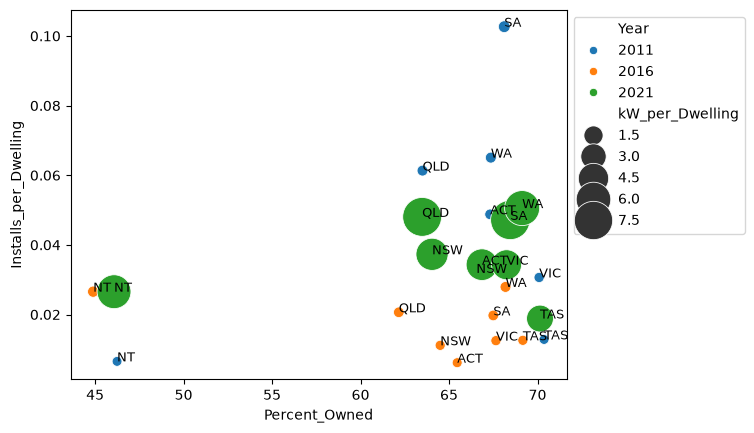

In [44]:
import seaborn as sns

# add the 'Year' to the existing dataframes
df_hypothesis_11['Year'] = '2011'
df_hypothesis_16['Year'] = '2016'
df_hypothesis['Year'] = '2021' 

# combine all 3 dataframes
df_visual_1 = pd.concat([df_hypothesis_11, df_hypothesis_16, df_hypothesis], ignore_index=True)

scatterplot = sns.scatterplot(
    data = df_visual_1, 
    x = 'Percent_Owned', 
    y = 'Installs_per_Dwelling', 
    size = 'kW_per_Dwelling', 
    sizes = (50, 800), 
    hue = 'Year',
)

# annotate each dot with the state names
for i, row in df_visual_1.iterrows():
    scatterplot.text(row['Percent_Owned'], row['Installs_per_Dwelling'], row['State'], fontsize=9)
    
# move the legend outside of the visuals
scatterplot.legend(bbox_to_anchor=(1, 1))


### VISUAL 2: ###

**Here we are trying to prove that we should rely on kW per Dwellings instead of kW per Person to make any judgements for this report**

**Note that if we apply the same logic for Installations, the results would also be similar**

In [45]:
# get the 2021 human population row 
df_pop_2021 = df_population_states[df_population_states['Year'] == 'Jun-2021'].copy()
df_pop_2021 = df_pop_2021.drop(columns=['Year', 'Whole country'])

df_pop_2021


,NSW,VIC,QLD,SA,WA,TAS,NT,ACT
40,8097062,6547822,5215814,1802601,2749365,567239,248151,452508


In [46]:
df_pop_2021_rotated = df_pop_2021.melt(var_name='State', value_name='Total_People')

df_pop_2021_rotated

,State,Total_People
0,NSW,8097062
1,VIC,6547822
2,QLD,5215814
3,SA,1802601
4,WA,2749365
5,TAS,567239
6,NT,248151
7,ACT,452508


In [47]:
df_compare = pd.merge(df_pop_2021_rotated, df_capacity_sub[['State', 'Total_Capacity_2021']], on='State', how='inner')

df_compare

,State,Total_People,Total_Capacity_2021
0,NSW,8097062,1.488295e+07
1,VIC,6547822,1.047215e+07
2,QLD,5215814,1.441212e+07
3,SA,1802601,5.461871e+06
4,WA,2749365,5.965140e+06
5,TAS,567239,7.478683e+05
6,NT,248151,4.053660e+05
7,ACT,452508,8.329271e+05


In [48]:
# get the Dwelling metric from df_final
df_compare = pd.merge(df_compare, df_final[['State', 'Capacity_kW_2021']], on='State', how='inner')
df_compare = df_compare.rename(columns={'Capacity_kW_2021': 'kW_per_Dwelling'})

df_compare['Total_Capacity_2021'] = pd.to_numeric(df_compare['Total_Capacity_2021'])
df_compare['Total_People'] = pd.to_numeric(df_compare['Total_People'])

# calculate kW per person
df_compare['kW_per_Person'] = df_compare['Total_Capacity_2021'] / df_compare['Total_People']


df_compare

,State,Total_People,Total_Capacity_2021,kW_per_Dwelling,kW_per_Person
0,NSW,8097062,1.488295e+07,5.131223,1.838068
1,VIC,6547822,1.047215e+07,4.381226,1.599333
2,QLD,5215814,1.441212e+07,7.709235,2.763159
3,SA,1802601,5.461871e+06,7.900721,3.029995
4,WA,2749365,5.965140e+06,6.183196,2.169643
5,TAS,567239,7.478683e+05,3.424117,1.318436
6,NT,248151,4.053660e+05,5.736852,1.633546
7,ACT,452508,8.329271e+05,4.946123,1.840690


In [49]:
# normalization math to force them into a 0 to 1 scale
df_compare['Normalized_Dwelling_Metric'] = df_compare['kW_per_Dwelling'] / df_compare['kW_per_Dwelling'].max()
df_compare['Normalized_People_Metric'] = df_compare['kW_per_Person'] / df_compare['kW_per_Person'].max()

df_compare

,State,Total_People,Total_Capacity_2021,kW_per_Dwelling,kW_per_Person,Normalized_Dwelling_Metric,Normalized_People_Metric
0,NSW,8097062,1.488295e+07,5.131223,1.838068,0.649463,0.606624
1,VIC,6547822,1.047215e+07,4.381226,1.599333,0.554535,0.527834
2,QLD,5215814,1.441212e+07,7.709235,2.763159,0.975763,0.911935
3,SA,1802601,5.461871e+06,7.900721,3.029995,1.000000,1.000000
4,WA,2749365,5.965140e+06,6.183196,2.169643,0.782612,0.716055
5,TAS,567239,7.478683e+05,3.424117,1.318436,0.433393,0.435128
6,NT,248151,4.053660e+05,5.736852,1.633546,0.726118,0.539125
7,ACT,452508,8.329271e+05,4.946123,1.840690,0.626034,0.607490


In [50]:
# reshape the data for Seaborn
df_melted = pd.melt(
    df_compare, 
    id_vars=['State'], 
    value_vars=['Normalized_Dwelling_Metric', 'Normalized_People_Metric'],
    var_name='Metric', 
    value_name='Normalized_Value'
)

# rename the values 
df_melted['Metric'] = df_melted['Metric'].replace({
    'Normalized_Dwelling_Metric': 'Standardised by Dwellings',
    'Normalized_People_Metric': 'Standardised by People'
})

df_melted

,State,Metric,Normalized_Value
0,NSW,Standardised by Dwellings,0.649463
1,VIC,Standardised by Dwellings,0.554535
2,QLD,Standardised by Dwellings,0.975763
3,SA,Standardised by Dwellings,1.000000
4,WA,Standardised by Dwellings,0.782612
5,TAS,Standardised by Dwellings,0.433393
6,NT,Standardised by Dwellings,0.726118
7,ACT,Standardised by Dwellings,0.626034
8,NSW,Standardised by People,0.606624
9,VIC,Standardised by People,0.527834


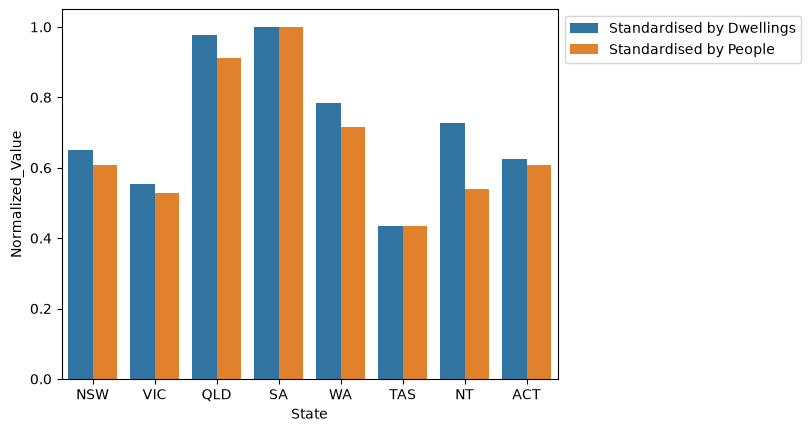

In [51]:
barplot = sns.barplot(
    data=df_melted, 
    x='State', 
    y='Normalized_Value', 
    hue='Metric', 
)

barplot.legend(bbox_to_anchor=(1, 1), loc='upper left')